# Veri Olarak Metin: Token'lar, Normalleştirme, Zipf — eşlik eden notebook

*Uygulamalı Doğal Dil İşleme — Token'lardan Ajanlara* kitabının 2. bölümü.
Önce bölümü okuyun: **[Veri Olarak Metin](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html)**.

Bölüm, bir karakter dizisi olan metni modelin kullanabileceği sayılara çeviriyor. Bunun
için iki karar gerekiyor: *birimlerin ne olduğu* (tokenleştirme) ve *her birimin hangi
sayıyla katkı vereceği* (ağırlıklandırma). Bölümün durum notu,
sayfadaki her sayının ve kod çıktısının kod çalıştırılarak üretildiğini söylüyor. Bu
notebook o kodu, bölümün sırasıyla çalıştırıyor:

1. **Karakterlerden token'lara**: boşluktan bölme, Türkçe küçük harf tuzağı, bir
   gövdeleyicinin neleri birleştirdiği, sıfırdan yazılmış bir byte-pair encoder, karakter
   ile bayt farkı, Türkçenin OpenAI tokenizer'larındaki maliyeti, gerçek bir tokenizer'ın
   dört aşaması, tek bir derlemin üç birim boyutu ve WordPiece ile Unigram LM üzerine
   derinleşme.
2. **Zipf ve Heaps yasaları**, 20 Newsgroups üzerinde; `min_df` ile stop word listesinin
   neleri sildiği, `'ax` artefaktı ve regresyon eğiminin neden güvenilir bir Zipf üssü
   olmadığının gösterimi dâhil.
3. **Bir kelime nasıl vektöre dönüşür**: dört bakım kaydından TF-IDF vektörlerine giden
   altı adım, kosinüs benzerliği ve $\lVert a-b \rVert^2 = 2 - 2\cos(a,b)$.
4. **Kelime torbasının yapamadıkları**: kelime sırası, n-gram'lar, olumsuzlama.
5. **Bütün bunların hâlâ bir önemi var mı?** Bölümün lojistik regresyon deneyi,
   farklarına uygulanan eşleştirilmiş test, üzerinde koştuğu seyrek matris ve BM25.
6. **Sezgi kontrollerinden ve mülakat sorularından çıkan sayılar.**

**Sayılar nasıl okunur.** Aşağıda basılan her şey *bu koşunun* ürettiği şey. Bölüm aynı
çıktıyı basıyorsa hücre kitabın değerini yanına yazıyor ya da basılan bloğun tamamını
satır satır karşılaştırıyor ve ikisinin tutup tutmadığını söylüyor. Bölümün çıktıyı basıp
kodu basmadığı yerlerde buradaki kod, metni bizim okuyuşumuz; hücre bunu da söylüyor.
Süreler makinenize bağlı.

**Dil hakkında bir not.** Anlatım ve kod yorumları Türkçe; kodun kendisi ve *basılan*
etiketler İngilizce. Bunun sebebi, Türkçe bölümlerin kendi `text` bloklarının da İngilizce
olması — böylece burada bastığınız tabloyla kitaptaki tablo yan yana okunabiliyor.

**Etkileşimli şekiller.** Bölümdeki etkileşimli araçlar (BPE birleştirme oynatıcısı, Zipf grafiği,
IDF eğrisi, belge-terim matrisi) Observable bileşenleri ve bir notebook'ta çalışamıyor.
Basılan sayıların öğretmediği bir şey öğrettikleri yerlerde küçük birer durağan grafik var.

**Süre.** Bir dizüstü CPU'sunda yaklaşık bir dakika; çoğu ilk indirme: 20 Newsgroups arşivi
(yaklaşık 14 MB), iki `tiktoken` sözlüğü (toplam yaklaşık 5 MB) ve Hugging Face Hub'dan üç
tokenizer dosyası (toplam yaklaşık 13 MB). Hiçbir hücre ağır değil, dolayısıyla
`ANLP_SKIP_HEAVY=1` burada bir şey değiştirmiyor.

## 0. Kurulum

İlk hücre yorumlayıcı ve paket sürümlerini kaydediyor. Bölümün durum notu `scikit-learn`
1.9, `tiktoken` 0.13, `sentencepiece` 0.2.2 ve `tokenizers` 0.22 diyor, metni de
`snowballstemmer` 3.1.1 sürümünü anıyor; kitabın kendi ölçümleri Python 3.14.5 üzerinde koştu
([Ek A](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/appendices/a-kurulum.html)). Sizin sayılarınız burada kayıtlı olanlardan
farklıysa önce bu hücreyi karşılaştırın.

İndirilenler, notebook deposunun kökündeki `data/cache/` altında önbelleğe alınıyor; git
orayı yoksayıyor, dolayısıyla ikinci koşu diskten okuyor. Depo dışında çalıştırırsanız
notebook onları kendi yanındaki `data/cache/` altına alıyor.

In [1]:
import io
import math
import os
import platform
import re
import sys
import time
import unicodedata
from collections import Counter
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

here = Path.cwd()
repo_root = next((p for p in [here, *here.parents] if (p / "scripts" / "check-structure.py").exists()), here)
CACHE = repo_root / "data" / "cache"
os.environ.setdefault("TIKTOKEN_CACHE_DIR", str(CACHE / "tiktoken"))  # tokenizer sözlükleri
DATA_HOME = str(CACHE / "scikit_learn_data")                           # 20 Newsgroups arşivi
os.environ.setdefault("HF_HOME", str(CACHE / "huggingface"))          # Hub'dan gelen tokenizer dosyaları
os.environ.setdefault("HF_HUB_VERBOSITY", "error")

print(f"Python        {platform.python_version()}  ({platform.system()} {platform.machine()})")
for pkg in ["numpy", "scipy", "scikit-learn", "tiktoken", "sentencepiece", "tokenizers",
            "snowballstemmer", "matplotlib"]:
    print(f"{pkg:<13} {version(pkg)}")

Python        3.12.13  (Darwin arm64)
numpy         2.5.2
scipy         1.18.1
scikit-learn  1.9.0
tiktoken      0.13.0
sentencepiece 0.2.2
tokenizers    0.22.2
snowballstemmer 3.1.1
matplotlib    3.11.2


Karşılaştırmayı iki yardımcı yapıyor. `vs_book` bir sayıyı kitabınkinin yanına, kitabın
bastığı hassasiyette koyuyor. `record()` bir hücrenin bastığı her şeyin kopyasını tutmaya
başlıyor ve `compare_with_book(...)` o kopyayı bölümün bastığı çıktı bloğuyla
karşılaştırıyor. Her karakter tutuyorsa *line for line* diyor; değerler tutup sütunlar
farklı doldurulmuşsa *only the spacing differs* diyor (kitap bazen NumPy dizilerini
dolgusu alınmış hâlde basıyor).

In [2]:
def vs_book(label, ours, book, fmt="{:,}"):
    """Print this run's value beside the book's, compared at the book's printed precision."""
    ours_s, book_s = fmt.format(ours), fmt.format(book)
    verdict = "same as the book" if ours_s == book_s else "DIFFERS from the book"
    print(f"{label:<38} this run {ours_s:>9}   book {book_s:>9}   {verdict}")


class _Tee(io.TextIOBase):
    """Writes to the notebook as usual and keeps a copy."""

    def __init__(self, stream):
        self.stream, self.copy = stream, io.StringIO()

    def write(self, s):
        self.copy.write(s)
        self.stream.write(s)
        return len(s)

    def flush(self):
        self.stream.flush()


def record():
    """Start keeping a copy of everything printed, to compare with the book's output."""
    if isinstance(sys.stdout, _Tee):
        sys.stdout = sys.stdout.stream
    sys.stdout = _Tee(sys.stdout)


def _squash(lines):
    """Collapse runs of spaces, and the padding NumPy puts inside brackets."""
    return [re.sub(r"\[ +| +\]", lambda m: m.group().strip(), " ".join(line.split())) for line in lines]


def compare_with_book(book_text):
    """Stop recording, and compare what was printed with the output block the book prints."""
    if not isinstance(sys.stdout, _Tee):
        raise RuntimeError("call record() before the code whose output you want to compare")
    ours_text = sys.stdout.copy.getvalue()
    sys.stdout = sys.stdout.stream
    ours = [line.rstrip() for line in ours_text.strip("\n").splitlines()]
    book = [line.rstrip() for line in book_text.strip("\n").splitlines()]
    print()
    if ours == book:
        print(f"-> same as the book, line for line ({len(book)} lines)")
    elif _squash(ours) == _squash(book):
        print(f"-> same values as the book ({len(book)} lines); only the spacing differs")
    else:
        print("-> DIFFERS from the book:")
        for k in range(max(len(ours), len(book))):
            o = ours[k] if k < len(ours) else "(no line)"
            b = book[k] if k < len(book) else "(no line)"
            if " ".join(o.split()) != " ".join(b.split()):
                print(f"   line {k + 1}\n     this run: {o}\n     book    : {b}")

## 1. Karakterlerden token'lara

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-tokenlar). Bir model herhangi bir şeyi sayabilmeden
önce, birinin "şey nedir" sorusuna cevap vermesi gerekiyor. Akla gelen ilk hamle
boşluklardan bölmek ve bu hamle anında başarısız oluyor.

**Neye bakacaksınız:** `fail;` ile `fail` farklı token'lar olurdu, `The` ile `the` de.

In [3]:
record()
text = "The pump P-101 didn't fail; it's the seal (again!)."
print(text.split())
compare_with_book("""
['The', 'pump', 'P-101', "didn't", 'fail;', "it's", 'the', 'seal', '(again!).']
""")

['The', 'pump', 'P-101', "didn't", 'fail;', "it's", 'the', 'seal', '(again!).']



-> same as the book, line for line (1 lines)


### 1a. Küçük harfe çevirme dile bağlı bir işlemdir

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-normallestirme). Python'un `str.lower()` metodu
Unicode'un *varsayılan* büyük-küçük harf eşlemesini uyguluyor, Türkçe uyarlamasını değil.
Türkçede iki `i` ve iki `I` harfi var, dolayısıyla varsayılan eşleme Türkçe için — hem de
sessizce — yanlış.

Bölümdeki üç satır sonuçlarını yorum olarak veriyor. Hücre ayrıca ilk iki karakterin kod
noktalarını listeliyor; böylece üstteki birleştirici noktayı (U+0307) görebiliyorsunuz.

In [4]:
lowered = "İSTANBUL".lower()
print(f'"İSTANBUL".lower() = {lowered!r}   code points of its first two characters: '
      f'{[f"U+{ord(c):04X}" for c in lowered[:2]]}')
print()
vs_book('len("İSTANBUL".lower())', len(lowered), 9)
vs_book('"İSTANBUL".lower() == "istanbul"', lowered == "istanbul", False, "{}")
vs_book('"IĞDIR".lower()', "IĞDIR".lower(), "iğdir", "{}")
print('\nwhat a Turkish reader expects from "IĞDIR": "ığdır"')

from sklearn.feature_extraction.text import CountVectorizer

vs_book("CountVectorizer's token for İSTANBUL", CountVectorizer().build_analyzer()("İSTANBUL"), ["stanbul"], "{}")

"İSTANBUL".lower() = 'i̇stanbul'   code points of its first two characters: ['U+0069', 'U+0307']

len("İSTANBUL".lower())                this run         9   book         9   same as the book
"İSTANBUL".lower() == "istanbul"       this run     False   book     False   same as the book
"IĞDIR".lower()                        this run     iğdir   book     iğdir   same as the book

what a Turkish reader expects from "IĞDIR": "ığdır"


CountVectorizer's token for İSTANBUL   this run ['stanbul']   book ['stanbul']   same as the book


**Nasıl okunur.** Hiçbir şey hata vermiyor. `İSTANBUL` dokuz kod noktasına dönüşüyor — `i`
artı birleştirici bir nokta — yani kullanıcının yazdığı `istanbul`dan farklı bir sözlük
sütununa düşüyor; `IĞDIR` ise Türkçenin `ığdır` istediği yerde `iğdir` oluyor.
[4. bölüm](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/04-karsilastirma.html) bu hatayı gerçek bir derlemde yakalıyor,
[16. bölüm](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/16-turkce-nlp.html#sec-turkce-nlp-normalizasyon) ise yerel ayara
duyarlı çözümü veriyor.

Son satır, bunun hattın ilerisinde neye yol açtığına dair bölümün örneği: varsayılan
`CountVectorizer` metni küçük harfe çeviriyor, token kalıbı da tek başına kalan `i` harfini
ve birleştirici noktayı atıyor; ortaya çıkan token `stanbul` oluyor.

Bölümün normalleştirme kısmındaki stop word kutusu 2. kısımdaki derlemi kullanıyor;
dolayısıyla onun kontrolü orada, derlem yüklendikten hemen sonra.

**Bir gövdeleyici neleri birleştirir.** Bölümün normalleştirme tablosu ve altındaki
paragraflar iki gövdeleyicinin (stemmer) çıktılarını veriyor: İngilizce için Porter ve
Türkçe için Snowball (`snowballstemmer` 3.1.1). Bölüm kod vermiyor. **Bizim okuyuşumuz:**
`snowballstemmer` kütüphanesinin `porter` ve `turkish` algoritmaları. Son üç Türkçe kelime
yalnızca Türkçe baskıda geçiyor.

**Neye bakacaksınız:** `university` ile `universe` farklı kelimeler olduğu hâlde
birleşiyor; `kullanıyorum` ile `kullandık` ise aynı fiilin biçimleri olduğu hâlde
birleşmiyor.

In [5]:
import snowballstemmer

porter, turkish = snowballstemmer.stemmer("porter"), snowballstemmer.stemmer("turkish")
for stemmer, pairs in [(porter, [("replaced", "replac"), ("university", "univers"), ("universe", "univers")]),
                       (turkish, [("kitaplarımızdan", "kitap"), ("kullanıyorum", "kullanıyor"),
                                  ("kullandık", "kulla"), ("gidiyorum", "gidiyor"),
                                  ("geldim", "gel"), ("gitti", "git")])]:
    for word, book in pairs:
        vs_book(word, stemmer.stemWord(word), book, "{}")

replaced                               this run    replac   book    replac   same as the book
university                             this run   univers   book   univers   same as the book
universe                               this run   univers   book   univers   same as the book
kitaplarımızdan                        this run     kitap   book     kitap   same as the book
kullanıyorum                           this run kullanıyor   book kullanıyor   same as the book
kullandık                              this run     kulla   book     kulla   same as the book
gidiyorum                              this run   gidiyor   book   gidiyor   same as the book
geldim                                 this run       gel   book       gel   same as the book
gitti                                  this run       git   book       git   same as the book


**Nasıl okunur.** Gövdeleyici ek kuralları uygular; kelimeyi sözlükte aramaz. `replac` ve
`kulla` birer kelime değil; iki biçimin aynı sütuna düşüp düşmeyeceğini de sözlük değil
kurallar belirliyor. Bölümün, bir gövdeleyiciye güvenmeden önce çıktılarına bakın demesinin
nedeni bu.

### 1b. Sıfırdan byte-pair encoding

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-bpe). Bölüm algoritmadan önce, hiç görülmemiş bir
kelimeyi üç birim boyutunda gösteriyor. Bütün kelime olarak `<UNK>` oluyor. Karakter olarak
hiçbir şey kaybolmuyor, ama kelime uzuyor ve hiçbir birim tek başına bir şey söylemiyor.
Alt kelime olarak ise modelin başka kelimelerden tanıdığı üç parçaya bölünüyor. Türkçe
baskı bunun için `evlerden` kelimesini, İngilizce baskı `unbreakable` kelimesini kullanıyor.
Bölüm, alt kelime satırının `cl100k_base` tokenizer'ının gerçekten yaptığı bölünme olduğunu
söylüyor; hücre bunu iki kelime için de kontrol ediyor.

`tiktoken`'ın ilk kullanımı kodlamanın sözlük dosyasını indiriyor; nereye kaydedildiğini 1d
kısmı söylüyor.

In [6]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")
for word, book in [("unbreakable", "un break able"), ("evlerden", "ev ler den")]:
    print(f"{word}: as characters, {len(word)} units: {' '.join(word)}")
    vs_book("  as subwords (cl100k_base)", " ".join(enc.decode([t]) for t in enc.encode(word)), book, "{}")

unbreakable: as characters, 11 units: u n b r e a k a b l e
  as subwords (cl100k_base)            this run un break able   book un break able   same as the book
evlerden: as characters, 8 units: e v l e r d e n
  as subwords (cl100k_base)            this run ev ler den   book ev ler den   same as the book


Şimdi bu parçaları bulan algoritma. Karakterlerle başlayın, her komşu çifti sayın, en sık
çifti yeni bir sembolde birleştirin, tekrarlayın. Kod bölümün kodu, satır satır.

**Neye bakacaksınız:** ilk üç birleştirme `est</w>`'yi kuruyor — İngilizce üstünlük eki ve
kelime sınırı — ve algoritmaya İngilizcenin ek aldığını kimse söylemedi.

In [7]:
record()
from collections import Counter

corpus = {"low": 5, "lower": 2, "newest": 6, "widest": 3}
words = {tuple(w) + ("</w>",): n for w, n in corpus.items()}

def pair_counts(words):
    pairs = Counter()
    for symbols, freq in words.items():
        for a, b in zip(symbols, symbols[1:]):
            pairs[(a, b)] += freq
    return pairs

def merge(words, pair):
    a, b = pair
    out = {}
    for symbols, freq in words.items():
        new, i = [], 0
        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == a and symbols[i + 1] == b:
                new.append(a + b)
                i += 2
            else:
                new.append(symbols[i])
                i += 1
        out[tuple(new)] = freq
    return out

merges = []
for step in range(1, 11):
    best, count = pair_counts(words).most_common(1)[0]
    merges.append(best)
    words = merge(words, best)
    print(f"merge {step:>2}: {best[0]!r} + {best[1]!r} -> "
          f"{best[0] + best[1]!r}  (seen {count} times)")
compare_with_book("""
merge  1: 'e' + 's' -> 'es'  (seen 9 times)
merge  2: 'es' + 't' -> 'est'  (seen 9 times)
merge  3: 'est' + '</w>' -> 'est</w>'  (seen 9 times)
merge  4: 'l' + 'o' -> 'lo'  (seen 7 times)
merge  5: 'lo' + 'w' -> 'low'  (seen 7 times)
merge  6: 'n' + 'e' -> 'ne'  (seen 6 times)
merge  7: 'ne' + 'w' -> 'new'  (seen 6 times)
merge  8: 'new' + 'est</w>' -> 'newest</w>'  (seen 6 times)
merge  9: 'low' + '</w>' -> 'low</w>'  (seen 5 times)
merge 10: 'w' + 'i' -> 'wi'  (seen 3 times)
""")

merge  1: 'e' + 's' -> 'es'  (seen 9 times)
merge  2: 'es' + 't' -> 'est'  (seen 9 times)
merge  3: 'est' + '</w>' -> 'est</w>'  (seen 9 times)
merge  4: 'l' + 'o' -> 'lo'  (seen 7 times)
merge  5: 'lo' + 'w' -> 'low'  (seen 7 times)
merge  6: 'n' + 'e' -> 'ne'  (seen 6 times)
merge  7: 'ne' + 'w' -> 'new'  (seen 6 times)
merge  8: 'new' + 'est</w>' -> 'newest</w>'  (seen 6 times)
merge  9: 'low' + '</w>' -> 'low</w>'  (seen 5 times)
merge 10: 'w' + 'i' -> 'wi'  (seen 3 times)



-> same as the book, line for line (10 lines)


Token'lara ayırmak için öğrenilen birleştirmeler, öğrenildikleri sırayla tekrar oynatılıyor.
`lowest` eğitimde hiç geçmedi. Bu hücre aynı zamanda bölümün etkileşimli BPE aracının notebook'taki
karşılığı: listeye kendi kelimelerinizi ekleyip yeniden çalıştırın.

In [8]:
record()
def apply_merges(word, merges):
    symbols = tuple(word) + ("</w>",)
    for pair in merges:
        symbols = tuple(merge({symbols: 1}, pair).keys())[0]
    return symbols

for w in ["lowest", "newer", "slow", "widest"]:
    print(f"{w:<8} -> {' '.join(apply_merges(w, merges))}")
compare_with_book("""
lowest   -> low est</w>
newer    -> new e r </w>
slow     -> s low</w>
widest   -> wi d est</w>
""")

lowest   -> low est</w>
newer    -> new e r </w>
slow     -> s low</w>
widest   -> wi d est</w>



-> same as the book, line for line (4 lines)


**Çekince.** Birleştirme tablosu *karakterler* üzerinde öğrenildi ve gördüğü alfabe
yalnızca `low`, `lower`, `newest` ve `widest` kelimelerinin harflerinden ibaretti.
Dolayısıyla görülmemiş bir **karakter** onu hâlâ kırıyor. Hücre bu küçük tokenizer'ın
bildiği sembolleri (başlangıç sembolleri artı on birleştirme) listeliyor ve `çay`ın her
parçasını onlara karşı kontrol ediyor.

In [9]:
pieces = apply_merges("çay", merges)
vs_book('apply_merges("çay", merges)', repr(pieces), "('ç', 'a', 'y', '</w>')", "{}")

known = {s for w in corpus for s in tuple(w) + ("</w>",)} | {a + b for a, b in merges}
print(f"\nsymbols the toy tokenizer knows ({len(known)}): {sorted(known)}")
for p in pieces:
    print(f"  {p!r:<7} {'known' if p in known else 'never seen in training'}")

apply_merges("çay", merges)            this run ('ç', 'a', 'y', '</w>')   book ('ç', 'a', 'y', '</w>')   same as the book

symbols the toy tokenizer knows (21): ['</w>', 'd', 'e', 'es', 'est', 'est</w>', 'i', 'l', 'lo', 'low', 'low</w>', 'n', 'ne', 'new', 'newest</w>', 'o', 'r', 's', 't', 'w', 'wi']
  'ç'     never seen in training
  'a'     never seen in training
  'y'     never seen in training
  '</w>'  known


**Nasıl okunur.** `ç`, `a` ve `y` eğitim kelimelerinde hiç geçmedi, dolayısıyla hiçbir
birleştirme onlara dokunamıyor. Dördüncü parça, yordamın her kelimeye eklediği kelime sonu
işareti `</w>`. Bayt düzeyinde çalışan tokenizer'lar bu açığı, karakterler yerine UTF-8'in
256 olası **baytından** başlayarak kapatıyor; nasıl yaptıklarını 1c kısmı gösteriyor.

### 1c. Karakter mi bayt mı: BPE neyle başlar

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-baytlar). Önce dört kavramı birbirinden ayırmak
gerekiyor. *Karakter*, ekranda gördüğünüz harf ya da işaret. Bilgisayar yalnızca sayı
saklar, bu yüzden her karaktere bir numara gerekir. *ASCII* (1963) bunlardan 128 tane
içerir: İngilizce harfler, rakamlar ve noktalama. *Unicode* aynı fikri bütün yazı
sistemlerine genişletir; bu numaraya karakterin *kod noktası* denir. *Bayt* 0 ile 255
arasında bir sayı tutar ve *UTF-8* kodlaması her kod noktasını bir ile dört bayt arasında
yazar.

Bölüm bunların hepsini `çay` kelimesi için küçük bir tabloda topluyor. Hücre tabloyu
yeniden kuruyor ve sayılarını kontrol ediyor.

**Neye bakacaksınız:** üç karakter, üç kod noktası, dört bayt.

In [10]:
shown = "çay"
print(f"{'':<22}" + "".join(f"{ch:>15}" for ch in shown))
print(f"{'Unicode code point':<22}" + "".join(f"{f'{ord(ch)} (U+{ord(ch):04X})':>15}" for ch in shown))
print(f"{'in the ASCII table?':<22}" + "".join(f"{'yes' if ord(ch) < 128 else 'no':>15}" for ch in shown))
print(f"{'UTF-8 bytes':<22}" + "".join(f"{', '.join(str(b) for b in ch.encode('utf-8')):>15}" for ch in shown))
print()
vs_book('characters: len("çay")', len(shown), 3)
vs_book('bytes: len("çay".encode("utf-8"))', len(shown.encode("utf-8")), 4)
vs_book("code point of ç", ord("ç"), 231)
vs_book("UTF-8 bytes of ç", list("ç".encode("utf-8")), [195, 167], "{}")

                                    ç              a              y
Unicode code point       231 (U+00E7)    97 (U+0061)   121 (U+0079)
in the ASCII table?                no            yes            yes
UTF-8 bytes                  195, 167             97            121

characters: len("çay")                 this run         3   book         3   same as the book
bytes: len("çay".encode("utf-8"))      this run         4   book         4   same as the book
code point of ç                        this run       231   book       231   same as the book
UTF-8 bytes of ç                       this run [195, 167]   book [195, 167]   same as the book


UTF-8, bir ASCII harfi için bir bayt, ASCII dışındaki Türkçe harfler için iki, Çince
karakterlerin çoğu için üç, emojilerin çoğu için dört bayt kullanıyor. Kod bölümün kodu.

In [11]:
record()
for ch in ["a", "ç", "ş", "İ", "世", "😀"]:
    b = ch.encode("utf-8")
    print(f"{ch}  U+{ord(ch):04X}  {len(b)} byte(s): {' '.join(f'{x:02X}' for x in b)}")
compare_with_book("""
a  U+0061  1 byte(s): 61
ç  U+00E7  2 byte(s): C3 A7
ş  U+015F  2 byte(s): C5 9F
İ  U+0130  2 byte(s): C4 B0
世  U+4E16  3 byte(s): E4 B8 96
😀  U+1F600  4 byte(s): F0 9F 98 80
""")

a  U+0061  1 byte(s): 61
ç  U+00E7  2 byte(s): C3 A7
ş  U+015F  2 byte(s): C5 9F
İ  U+0130  2 byte(s): C4 B0
世  U+4E16  3 byte(s): E4 B8 96
😀  U+1F600  4 byte(s): F0 9F 98 80



-> same as the book, line for line (6 lines)


**Baytlardan başlamak.** Baytlardan başlayan bir tokenizer'ın alfabesi baştan tamdır, çünkü
her dildeki her metin 256 bayt değerinin bir dizisidir. Aşağıda OpenAI'ın bayt düzeyindeki
`cl100k_base` kodlaması, her token'ın arkasındaki baytları gösteriyor. Kod bölümün kodu.

**Neye bakacaksınız:** `ç` tek token, `ŞİŞE` `şişe`'nin iki katına mal oluyor ve hiçbir şey
`<UNK>` olmuyor.

In [12]:
record()
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")
for text in ["çay", "şişe", "ŞİŞE", "😀"]:
    pieces = [enc.decode_single_token_bytes(t) for t in enc.encode(text)]
    print(f"{text:<5} {len(pieces)} tokens  {pieces}")
compare_with_book("""
çay   2 tokens  [b'\\xc3\\xa7', b'ay']
şişe  3 tokens  [b'\\xc5\\x9fi', b'\\xc5\\x9f', b'e']
ŞİŞE  6 tokens  [b'\\xc5', b'\\x9e', b'\\xc4\\xb0', b'\\xc5', b'\\x9e', b'E']
😀     2 tokens  [b'\\xf0\\x9f\\x98', b'\\x80']
""")

çay   2 tokens  [b'\xc3\xa7', b'ay']
şişe  3 tokens  [b'\xc5\x9fi', b'\xc5\x9f', b'e']
ŞİŞE  6 tokens  [b'\xc5', b'\x9e', b'\xc4\xb0', b'\xc5', b'\x9e', b'E']
😀     2 tokens  [b'\xf0\x9f\x98', b'\x80']



-> same as the book, line for line (4 lines)


**Ama baytlar karakterlere saygı duymuyor.** Bölümün düzeltmesi: bayt düzeyinde BPE sık
geçen *bayt* dizilerini birleştiriyor ve birleştirmeler Unicode karakter sınırlarına bağlı
değil. Sık geçen karakterlerin çoğu gerçekten tek token oluyor, ama bir token birkaç
karakteri de, bir karakterin yalnızca bir parçasını da temsil edebiliyor. Aşağıdaki hücre
her token'ın baytlarını tek başına çözüyor ve o baytların geçerli UTF-8 olup olmadığını
bildiriyor.

In [13]:
import tiktoken

def boundary_report(enc_name, strings):
    enc = tiktoken.get_encoding(enc_name)
    print(f"{enc_name}")
    for s in strings:
        parts = [enc.decode_single_token_bytes(t) for t in enc.encode(s)]
        kind = []
        for b in parts:
            try:
                b.decode("utf-8")
                kind.append("whole")
            except UnicodeDecodeError:
                kind.append("PARTIAL")
        print(f"  {s:<22} {len(parts):>2} tokens  {kind}")
        print(f"  {'':<22}    {parts}")
    print()


for name in ["cl100k_base", "o200k_base"]:
    boundary_report(name, ["çay", "😀", "🇹🇷", "世界"])

cl100k_base
  çay                     2 tokens  ['whole', 'whole']
                            [b'\xc3\xa7', b'ay']
  😀                       2 tokens  ['PARTIAL', 'PARTIAL']
                            [b'\xf0\x9f\x98', b'\x80']
  🇹🇷                      6 tokens  ['PARTIAL', 'PARTIAL', 'PARTIAL', 'PARTIAL', 'PARTIAL', 'PARTIAL']
                            [b'\xf0\x9f', b'\x87', b'\xb9', b'\xf0\x9f', b'\x87', b'\xb7']
  世界                      3 tokens  ['PARTIAL', 'PARTIAL', 'whole']
                            [b'\xe4\xb8', b'\x96', b'\xe7\x95\x8c']



o200k_base
  çay                     2 tokens  ['whole', 'whole']
                            [b'\xc3\xa7', b'ay']
  😀                       1 tokens  ['whole']
                            [b'\xf0\x9f\x98\x80']
  🇹🇷                      4 tokens  ['PARTIAL', 'PARTIAL', 'PARTIAL', 'PARTIAL']
                            [b'\xf0\x9f\x87', b'\xb9', b'\xf0\x9f\x87', b'\xb7']
  世界                      1 tokens  ['whole']
                            [b'\xe4\xb8\x96\xe7\x95\x8c']



**Nasıl okunur.** `çay` iki token'a bölünüyor ve ikisi de geçerli UTF-8 — Türkçe `ç`
gerçekten tek token olmuş, ki sık bir karakter için olağan olan bu. Emoji ise karşı örnek:
`cl100k_base` altında `😀` iki token ve *hiçbiri* tek başına geçerli bir karakter değil;
birleştirme tablosu dört baytlık bir dizinin ortasından kesmiş. Türk bayrağı `🇹🇷` böyle
altı parça. Daha sonra ve daha büyük bir sözlükle eğitilen `o200k_base` `😀`'yı bütün
tutuyor ama bayrağı hâlâ bölüyor.

"Sık geçen bayt çiftleri önce birleşip tam karakterlere dönüşür" cümlesinin neden yanlış
bir zihinsel model olduğu bu. Algoritmanın hiçbir yerinde karakterin nerede bittiği
bilinmiyor. Pratikte şurada canınızı yakıyor: bir token dizisini keserken, prompt'u
rastgele bir token'dan bölmek elinizde yarım bir karakter bırakabilir.

**Byte fallback.** İki seçeneği birleştiren üçüncü bir tasarım. Sözlük karakterlerden
kurulur, ama içine 256 bayt değerinin her biri için birer token eklenir. Tokenizer
tanımadığı bir karakterle karşılaşınca `<UNK>` yazmak yerine o karakterin UTF-8 baytlarını
bu token'larla yazar. Bölüm, SentencePiece'i içinde hiç `ç` geçmeyen sekiz Türkçe kelimeyle
iki kez eğitiyor: bir kez bu seçenek kapalı, bir kez açık. Sonra ikisine de `çay` kelimesini
veriyor.

Kod bölümün kodu, tek bir farkla: bölüm üç küçük dosyasını çalışma dizinine yazıyor, bu
hücre ise depoya karışmasınlar diye `data/cache/` altına yazıyor.

**Neye bakacaksınız:** her satırın sonu, yani token'ların yeniden metne çevrilmiş hâli.

In [14]:
record()
import sentencepiece as spm

mini = CACHE / "sentencepiece-mini"                 # kitapta yok: dosyaları önbellekte tut
mini.mkdir(parents=True, exist_ok=True)

words = ["ev", "evde", "evden", "evler", "yol", "yolda", "yoldan", "yollar"]
with open(mini / "mini.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(words * 5) + "\n")            # bu metinde hiç 'ç' yok

for fallback in [False, True]:
    spm.SentencePieceTrainer.train(
        input=str(mini / "mini.txt"), model_prefix=str(mini / "mini"), model_type="bpe",
        vocab_size=20 + (256 if fallback else 0), byte_fallback=fallback,
        character_coverage=1.0, hard_vocab_limit=False, minloglevel=2,
        bos_id=-1, eos_id=-1, pad_id=-1)
    sp = spm.SentencePieceProcessor(model_file=str(mini / "mini.model"))
    ids = sp.encode("çay")
    print(f"byte_fallback={fallback!s:<5}  vocabulary {sp.get_piece_size():>3}  "
          f"{sp.encode('çay', out_type=str)}  ->  {sp.decode(ids)!r}")
compare_with_book("""
byte_fallback=False  vocabulary  20  ['▁', 'ç', 'a', 'y']  ->  ' ⁇ ay'
byte_fallback=True   vocabulary 276  ['▁', '<0xC3>', '<0xA7>', 'a', 'y']  ->  'çay'
""")

byte_fallback=False  vocabulary  20  ['▁', 'ç', 'a', 'y']  ->  ' ⁇ ay'
byte_fallback=True   vocabulary 276  ['▁', '<0xC3>', '<0xA7>', 'a', 'y']  ->  'çay'



-> same as the book, line for line (2 lines)


**Nasıl okunur.** Seçenek kapalıyken `ç` "bilinmeyen" kimliğini alıyor ve geri çevirince
yerinde `⁇` kalıyor: harf kayboldu. Açıkken sözlük 256 bayt token'ı kadar büyümüş (20'den
276'ya) ve `ç`, `<0xC3>` `<0xA7>` olarak yazılıyor. Bunlar yukarıdaki `çay` tablosundaki iki
bayt: onaltılık C3 = 195, A7 = 167. Metne geri çevirince `çay` eksiksiz dönüyor. Baştaki
`▁`, kelimenin başladığı yeri gösteren işaret; 1d kısmı ona geri dönüyor.

### 1d. Türkçe için faturayı kim ödüyor

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-turkce). İnsan Hakları Evrensel Bildirgesi'nin 1.
maddesi, resmî İngilizce ve Türkçe metinleriyle (Birleşmiş Milletler yayını) OpenAI'ın iki
tokenizer'ından geçiriliyor. Kod bölümün kodu. Uzunluklar Unicode kod noktası olarak
sayılıyor; Python'da `len` bir metin için bunu döndürür.

İlk çağrı her kodlamanın sözlük dosyasını OpenAI'ın herkese açık blob deposundan indiriyor
ve `data/cache/tiktoken` altında önbelleğe alıyor. Bölüm bu kısımdaki her ölçümün Unicode
NFC normalleştirmesinden sonra alındığını söylüyor; hücre de iki metnin zaten NFC
olduğunu kontrol ediyor.

In [15]:
record()
import tiktoken

en = ("All human beings are born free and equal in dignity and rights. "
      "They are endowed with reason and conscience and should act towards "
      "one another in a spirit of brotherhood.")
tr = ("Bütün insanlar hür, haysiyet ve haklar bakımından eşit doğarlar. "
      "Akıl ve vicdana sahiptirler ve birbirlerine karşı kardeşlik "
      "zihniyeti ile hareket etmelidirler.")

for name in ["cl100k_base", "o200k_base"]:
    enc = tiktoken.get_encoding(name)
    a, b = len(enc.encode(en)), len(enc.encode(tr))
    print(f"{name}:")
    print(f"  english : {len(en):>4} code points -> {a:>3} tokens  "
          f"({len(en) / a:4.2f} code points/token)")
    print(f"  turkish : {len(tr):>4} code points -> {b:>3} tokens  "
          f"({len(tr) / b:4.2f} code points/token)")
    print(f"  Turkish/English token count ratio: {b / a:4.2f}")
compare_with_book("""
cl100k_base:
  english :  170 code points ->  33 tokens  (5.15 code points/token)
  turkish :  160 code points ->  60 tokens  (2.67 code points/token)
  Turkish/English token count ratio: 1.82
o200k_base:
  english :  170 code points ->  33 tokens  (5.15 code points/token)
  turkish :  160 code points ->  46 tokens  (3.48 code points/token)
  Turkish/English token count ratio: 1.39
""")
print("both strings already NFC:", unicodedata.is_normalized("NFC", en) and unicodedata.is_normalized("NFC", tr))

cl100k_base:
  english :  170 code points ->  33 tokens  (5.15 code points/token)
  turkish :  160 code points ->  60 tokens  (2.67 code points/token)
  Turkish/English token count ratio: 1.82
o200k_base:
  english :  170 code points ->  33 tokens  (5.15 code points/token)
  turkish :  160 code points ->  46 tokens  (3.48 code points/token)
  Turkish/English token count ratio: 1.39



-> same as the book, line for line (8 lines)
both strings already NFC: True


**Bir Türkçe kelime, dört ek.** Bölüm, ekler üst üste binerken tokenizer'ın `ev`i nasıl
böldüğünü basıyor ama kodu basmıyor. `' ev'`in başındaki boşluk, kelimenin bir boşluktan
sonra — yani cümle ortasında görüneceği gibi — kodlandığını söylüyor. **Bizim okuyuşumuz:**
`cl100k_base`, her kelimenin önünde bir boşluk. Hücre ayrıca bölümün üç token dediği
İngilizce çeviriyi, *from our houses*, sayıyor ve bölümün şu notunu kontrol ediyor: daha
yeni `o200k_base`, `imiz` parçasını bölmeden tutuyor.

In [16]:
enc = tiktoken.get_encoding("cl100k_base")

record()
for w in ["ev", "evler", "evlerimiz", "evlerimizden"]:
    ids = enc.encode(" " + w)
    print(f"{w:<14} {len(ids)} tokens  {[enc.decode([i]) for i in ids]}")
compare_with_book("""
ev             1 tokens  [' ev']
evler          2 tokens  [' ev', 'ler']
evlerimiz      4 tokens  [' ev', 'ler', 'im', 'iz']
evlerimizden   5 tokens  [' ev', 'ler', 'im', 'iz', 'den']
""")
print()
vs_book('tokens in " from our houses"', len(enc.encode(" from our houses")), 3)
o200k = tiktoken.get_encoding("o200k_base")
vs_book("o200k_base splits evlerimizden as",
        "|".join(o200k.decode([i]) for i in o200k.encode(" evlerimizden")).strip(), "ev|ler|imiz|den", "{}")

ev             1 tokens  [' ev']
evler          2 tokens  [' ev', 'ler']
evlerimiz      4 tokens  [' ev', 'ler', 'im', 'iz']
evlerimizden   5 tokens  [' ev', 'ler', 'im', 'iz', 'den']



-> same as the book, line for line (4 lines)

tokens in " from our houses"           this run         3   book         3   same as the book
o200k_base splits evlerimizden as      this run ev|ler|imiz|den   book ev|ler|imiz|den   same as the book


**Nasıl okunur.** `ev|ler|im|iz|den` dört sınırının üçünde gerçek biçimbilimle örtüşüyor.
Bölümün çekince koyduğu yer `im|iz`: *-imiz* tek bir biçimbirim ve BPE onu ikiye bölmüş,
çünkü `im` ve `iz` ayrı ayrı sık geçiyor. `o200k_base` bu kesimi yapmıyor; bu da kesimin
dile değil, birleştirme tablosuna bağlı olduğunu gösteriyor.

**Boşluklar nereye gitti?** Yukarıdaki ilk token `' ev'`, yani başında bir boşluk var.
GPT'nin BPE tokenizer'ları ve BERT'in WordPiece'i metni önce boşluk ve noktalamadan
kelimelere böler (*ön tokenleştirme*), alt kelimelere bölmeyi ancak ondan sonra, her
kelimenin içinde yapar. Bu yüzden hiçbir token iki kelimeye birden yayılmaz. Token'ları
yeniden metne çevirebilmek için kelimenin nerede başladığının token'ın üzerine yazılması
gerekir ve üç tokenizer ailesi bunu üç farklı işaretle yapıyor. Bölümün tablosu aynı iki
kelimeyi, `evlerimizden geldik`, üçünde de gösteriyor ama kodunu vermiyor. **Bizim
okuyuşumuz:** tabloda adı geçen üç tokenizer; boşluk, tablodaki gibi `␣` ile basılıyor.

Hücre Hugging Face Hub'dan iki tokenizer dosyası indirip `data/cache/huggingface` altında
önbelleğe alıyor: çok dilli BERT'inki (2 MB, Apache-2.0) ve XLM-R'ınki (9 MB, MIT).

In [17]:
from tokenizers import Tokenizer

two_words = "evlerimizden geldik"
gpt = tiktoken.get_encoding("cl100k_base")
xlmr = Tokenizer.from_pretrained("FacebookAI/xlm-roberta-base")
mbert = Tokenizer.from_pretrained("google-bert/bert-base-multilingual-cased")

rows = [
    ("GPT (cl100k_base)",
     [gpt.decode([t]).replace(" ", "␣") for t in gpt.encode(two_words)],
     "ev ler im iz den ␣geld ik"),
    ("SentencePiece (XLM-R)",
     xlmr.encode(two_words, add_special_tokens=False).tokens,
     "▁ev lerimiz den ▁geldi k"),
    ("WordPiece (multilingual BERT)",
     mbert.encode(two_words, add_special_tokens=False).tokens,
     "ev ##leri ##mi ##zde ##n geldi ##k"),
]
for family, tokens, book in rows:
    vs_book(family, " ".join(tokens), book, "{}")

GPT (cl100k_base)                      this run ev ler im iz den ␣geld ik   book ev ler im iz den ␣geld ik   same as the book
SentencePiece (XLM-R)                  this run ▁ev lerimiz den ▁geldi k   book ▁ev lerimiz den ▁geldi k   same as the book
WordPiece (multilingual BERT)          this run ev ##leri ##mi ##zde ##n geldi ##k   book ev ##leri ##mi ##zde ##n geldi ##k   same as the book


**Nasıl okunur.** GPT boşluğu *sonraki* kelimenin ilk token'ına yapıştırıyor (`␣geld`).
SentencePiece kelimenin başına görünür bir `▁` koyuyor. WordPiece tersini işaretliyor:
kelimenin *devamı* olan her parçanın başına `##` koyuyor. Üçü de aynı bilgiyi taşıyor:
burada yeni bir kelime başlıyor.

**Bir tokenizer'ın dört aşaması.** Metin modele gitmeden önce dört aşamadan geçer:
normalleştirme, ön tokenleştirme, alt kelime kodlaması ve özel token'lar. Bölüm Türkçe bir
cümleyi `bert-base-multilingual-uncased` tokenizer'ında (2 MB'lık bir dosya, Apache-2.0)
adım adım izliyor. Kod bölümün kodu.

**Neye bakacaksınız:** ilk satır; `Çay` orada `cay` oluyor.

In [18]:
record()
from tokenizers import Tokenizer

tok = Tokenizer.from_pretrained("google-bert/bert-base-multilingual-uncased")
text = "Çay içtik, sonra evlerimizden çıktık."

norm = tok.normalizer.normalize_str(text)
print("1 normalize    :", norm)
print("2 pre-tokenize :", [w for w, _ in tok.pre_tokenizer.pre_tokenize_str(norm)])
print("3 subwords     :", tok.encode(text, add_special_tokens=False).tokens)
print("4 special      :", tok.encode(text).tokens)
print("  ids          :", tok.encode(text).ids)
compare_with_book("""
1 normalize    : cay ictik, sonra evlerimizden cıktık.
2 pre-tokenize : ['cay', 'ictik', ',', 'sonra', 'evlerimizden', 'cıktık', '.']
3 subwords     : ['cay', 'ic', '##tik', ',', 'sonra', 'ev', '##leri', '##mi', '##zde', '##n', 'cıktı', '##k', '.']
4 special      : ['[CLS]', 'cay', 'ic', '##tik', ',', 'sonra', 'ev', '##leri', '##mi', '##zde', '##n', 'cıktı', '##k', '.', '[SEP]']
  ids          : [101, 21373, 11797, 13537, 117, 12624, 18110, 12737, 10555, 55567, 10115, 59161, 10167, 119, 102]
""")
print()
vs_book("the cased model leaves the text as it is", mbert.normalizer.normalize_str(text) == text, True, "{}")

1 normalize    : cay ictik, sonra evlerimizden cıktık.
2 pre-tokenize : ['cay', 'ictik', ',', 'sonra', 'evlerimizden', 'cıktık', '.']
3 subwords     : ['cay', 'ic', '##tik', ',', 'sonra', 'ev', '##leri', '##mi', '##zde', '##n', 'cıktı', '##k', '.']
4 special      : ['[CLS]', 'cay', 'ic', '##tik', ',', 'sonra', 'ev', '##leri', '##mi', '##zde', '##n', 'cıktı', '##k', '.', '[SEP]']
  ids          : [101, 21373, 11797, 13537, 117, 12624, 18110, 12737, 10555, 55567, 10115, 59161, 10167, 119, 102]



-> same as the book, line for line (5 lines)

the cased model leaves the text as it is this run      True   book      True   same as the book


**Nasıl okunur.** Her satır bir aşama. Normalleştirme metni küçük harfe çevirdi ve
harflerin üzerindeki işaretleri attı; model artık `çay` ile `cay` arasındaki farkı göremez.
`ı` yerinde kaldı, çünkü Unicode onu ayrı bir harf olarak tanımlıyor. Ön tokenleştirme
virgülü ve noktayı ayrı birer parça yaptı. Alt kelime kodlaması her kelimenin içinde
çalıştı: `evlerimizden` beş parça, `sonra` bütün kaldı. Son aşama `[CLS]` ve `[SEP]`
ekledi; tamsayılar modele gerçekten giden şey. Aynı modelin büyük/küçük harfe duyarlı
sürümü, bölümün dediği gibi, ilk aşamada metne dokunmuyor.

**Pratik bir ayrıntı: NFC.** `ö` gibi işaretli bir harf tek bir kod noktası olarak ya da
`o` harfi ile ayrı bir birleştirici işaret olarak saklanabilir. İkisi ekranda aynı görünür,
ama tokenizer onları farklı sayar. Bölümün önerisi bu yüzden tokenizer'dan önce tek bir
satır: `unicodedata.normalize("NFC", text)`. Bölüm bunun için sayı vermiyor; aşağıdakiler
bu koşunun, tek bir kelime üzerindeki sayıları.

In [19]:
shown = "görüşebileceklerimiz"
nfc, nfd = unicodedata.normalize("NFC", shown), unicodedata.normalize("NFD", shown)
print(f"NFC: {nfc}   {len(nfc)} code points, {len(nfc.encode('utf-8'))} bytes")
print(f"NFD: {nfd}   {len(nfd)} code points, {len(nfd.encode('utf-8'))} bytes")
print(f"equal in Python: {nfc == nfd}")
for name in ["cl100k_base", "o200k_base"]:
    e = tiktoken.get_encoding(name)
    print(f"{name:<12} NFC {len(e.encode(nfc)):>2} tokens   NFD {len(e.encode(nfd)):>2} tokens")
print(f"equal after normalize('NFC', ...): {unicodedata.normalize('NFC', nfd) == nfc}")

NFC: görüşebileceklerimiz   20 code points, 23 bytes
NFD: görüşebileceklerimiz   23 code points, 26 bytes
equal in Python: False
cl100k_base  NFC 10 tokens   NFD 15 tokens
o200k_base   NFC  7 tokens   NFD 10 tokens
equal after normalize('NFC', ...): True


**Nasıl okunur.** İki yazım aynı görünüyor, eşit karşılaştırılmıyor ve ayrıştırılmış olan
iki kodlamada da daha fazla token'a mal oluyor. Tek bir çağrı onları yeniden aynı metin
yapıyor.

**Neden doğrudan karakter kullanmıyoruz?** Bölümün sezgi kontrolü aynı Türkçe cümleyi üç
birim boyutunda sayıyor ve her sayının karesini alıyor; çünkü self-attention her birimi
diğer bütün birimlerle karşılaştırır. Kod bölümün kodu; `tr`, yukarıdaki hücredeki 1.
maddenin Türkçe metni.

**Neye bakacaksınız:** ortadaki sütun, sonra hemen yanındaki.

In [20]:
record()
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")
units = {
    "code points": list(tr),
    "subword tokens": [enc.decode([t]) for t in enc.encode(tr)],
    "words": tr.split(),
}
for name, seq in units.items():
    n = len(seq)
    print(f"{name:<15} {n:>3} units  {n * n:>6,} pairs  first six: {seq[:6]}")
compare_with_book("""
code points     160 units  25,600 pairs  first six: ['B', 'ü', 't', 'ü', 'n', ' ']
subword tokens   60 units   3,600 pairs  first six: ['B', 'üt', 'ün', ' insan', 'lar', ' h']
words            21 units     441 pairs  first six: ['Bütün', 'insanlar', 'hür,', 'haysiyet', 've', 'haklar']
""")

code points     160 units  25,600 pairs  first six: ['B', 'ü', 't', 'ü', 'n', ' ']
subword tokens   60 units   3,600 pairs  first six: ['B', 'üt', 'ün', ' insan', 'lar', ' h']
words            21 units     441 pairs  first six: ['Bütün', 'insanlar', 'hür,', 'haysiyet', 've', 'haklar']



-> same as the book, line for line (3 lines)


**Nasıl okunur.** Kod noktaları en uzun diziyi veriyor: 160 birim ve 25.600 çift. Bütün
kelimeler en kısasını veriyor, 21 birim; ama kelime düzeyinde bir sözlük hiç görmediği
biçimlerle karşılaşır. Alt kelimeler ikisinin arasında kalıyor. Sayılar bu cümleye ve bu
tokenizer'a ait.

### 1e. Karakter, alt kelime, bütün kelime: tek bir örnek

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-birimler). Küçük bir derlem, üç tokenizer. Derlem on
iki Türkçe gövdenin beşer biçiminden oluşuyor: 60 biçim ve 216 geçiş. İki test kelimesi,
`evlerden` ve `okullardan`, bunların arasında yok. Kod bölümün kodu; 1b kısmındaki
`pair_counts`, `merge` ve `apply_merges` fonksiyonlarını yeniden kullanıyor.

**Neye bakacaksınız:** her tokenizer'ın, görmediği iki kelime için kaç birime ihtiyaç
duyduğu.

In [21]:
record()
stems = {"ev": "e", "el": "e", "göl": "e", "köy": "e", "gün": "e", "yüz": "e",
         "okul": "a", "yol": "a", "kol": "a", "yıl": "a", "kız": "a", "masa": "a"}
corpus = {}
for stem, v in stems.items():          # v: eklerin alacağı ünlü
    for suffix, n in [("", 4), (f"l{v}r", 2), (f"d{v}", 4),
                      (f"d{v}n", 4), (f"l{v}rd{v}", 4)]:
        corpus[stem + suffix] = n      # ev, evler, evde, evden, evlerde, ...
test = ["evlerden", "okullardan"]      # iki kelime de derlemde yok

chars = sorted({c for word in corpus for c in word})
words = {tuple(w) + ("</w>",): n for w, n in corpus.items()}
merges = []
while len(chars) + 1 + len(merges) < 60:   # sözlük 60 sembole ulaşınca dur
    best, _ = pair_counts(words).most_common(1)[0]
    merges.append(best)
    words = merge(words, best)

tokenizers = {
    "whole words": (len(corpus), lambda w: [w if w in corpus else "<UNK>"]),
    "characters": (len(chars), lambda w: list(w)),
    "subwords (BPE)": (len(chars) + 1 + len(merges),
                       lambda w: list(apply_merges(w, merges))),
}
for name, (size, split) in tokenizers.items():
    pieces = [p for w in test for p in split(w)]
    print(f"{name:<15} vocabulary {size:>2}   {len(pieces):>2} units: {' '.join(pieces)}")
compare_with_book("""
whole words     vocabulary 60    2 units: <UNK> <UNK>
characters      vocabulary 18   18 units: e v l e r d e n o k u l l a r d a n
subwords (BPE)  vocabulary 60    6 units: ev ler den</w> okul lar dan</w>
""")
print()
vs_book("forms in the corpus", len(corpus), 60)
vs_book("occurrences in the corpus", sum(corpus.values()), 216)

whole words     vocabulary 60    2 units: <UNK> <UNK>
characters      vocabulary 18   18 units: e v l e r d e n o k u l l a r d a n
subwords (BPE)  vocabulary 60    6 units: ev ler den</w> okul lar dan</w>



-> same as the book, line for line (3 lines)

forms in the corpus                    this run        60   book        60   same as the book
occurrences in the corpus              this run       216   book       216   same as the book


**Nasıl okunur.** Bütün kelime tokenizer'ının 60 girdisi var ve yine de iki kez `<UNK>`
diyor. Karakter tokenizer'ına 18 sembol yetiyor ve hiçbir şey kaybolmuyor, ama iki kelimeye
18 birim harcıyor. Kelime listesiyle aynı 60 girdide durdurulan BPE ise iki kelimeyi altı
parçayla karşılıyor; bu parçaları başka kelimelerden öğrendi.

### Derinleşme: aynı derlemde WordPiece ve Unigram LM

Bölümün kapalı gelen derinleşme kutusu bu derlemde iki alt kelime öğrenicisi daha eğitiyor;
her biri birkaç on satır. Bunlar öğretim amaçlı gerçekleştirimler: buradaki WordPiece en
sık çifti değil, $\frac{\text{sayım}(ab)}{\text{sayım}(a)\,\text{sayım}(b)}$ puanı en
yüksek çifti birleştiriyor; Unigram LM ise bütün alt dizilerle başlayıp buduyor. Kod
bölümün kodu.

In [22]:
import math

def train_wordpiece(corpus, size):
    words = {tuple([w[0]] + ["##" + c for c in w[1:]]): n for w, n in corpus.items()}
    vocab = {s for symbols in words for s in symbols}
    first = None
    while len(vocab) < size:
        pairs, single = Counter(), Counter()
        for symbols, n in words.items():
            for s in symbols:
                single[s] += n
            for a, b in zip(symbols, symbols[1:]):
                pairs[(a, b)] += n
        score = {p: c / (single[p[0]] * single[p[1]]) for p, c in pairs.items()}
        best = max(score, key=lambda p: (score[p], p))
        first = first or (pairs, score)
        glued = best[0] + best[1].removeprefix("##")
        new = {}
        for symbols, n in words.items():
            out, i = [], 0
            while i < len(symbols):
                if symbols[i:i + 2] == best:
                    out.append(glued)
                    i += 2
                else:
                    out.append(symbols[i])
                    i += 1
            new[tuple(out)] = n
        words, vocab = new, vocab | {glued}
    return vocab, first

def wordpiece_split(word, vocab):          # açgözlü: önce bilinen en uzun parça
    pieces, start = [], 0
    while start < len(word):
        for end in range(len(word), start, -1):
            piece = word[start:end] if start == 0 else "##" + word[start:end]
            if piece in vocab:
                break
        else:
            return ["[UNK]"]
        pieces.append(piece)
        start = end
    return pieces

def best_split(word, logp):                # Viterbi: en olası bölünme
    best = [(0.0, [])] + [(-math.inf, None)] * len(word)
    for end in range(1, len(word) + 1):
        for start in range(end):
            piece = word[start:end]
            if piece in logp and best[start][1] is not None:
                score = best[start][0] + logp[piece]
                if score > best[end][0]:
                    best[end] = (score, best[start][1] + [piece])
    return best[-1]

def train_unigram(corpus, size):
    counts = Counter()                     # büyük başla: her alt dizi (substring)
    for w, n in corpus.items():
        for i in range(len(w)):
            for j in range(i + 1, len(w) + 1):
                counts[w[i:j]] += n
    start_size = len(counts)
    logprobs = lambda c: {p: math.log(k / sum(c.values())) for p, k in c.items()}
    loss = lambda lp: -sum(n * best_split(w, lp)[0] for w, n in corpus.items())
    while len(counts) > size:
        lp = logprobs(counts)
        base = loss(lp)
        cost = {p: loss({q: v for q, v in lp.items() if q != p}) - base
                for p in counts if len(p) > 1}     # tek harfler her zaman kalır
        k = max(1, min(len(counts) - size, len(cost) // 5))
        for p in sorted(cost, key=lambda p: (cost[p], p))[:k]:
            del counts[p]                  # en ucuza mal olan parçaları buda
        lp = logprobs(counts)              # en iyi bölünmelerden yeniden kestir
        counts = Counter({p: 0.001 for p in counts})
        for w, n in corpus.items():
            for piece in best_split(w, lp)[1]:
                counts[piece] += n
    return logprobs(counts), start_size

In [23]:
record()
wp_vocab, (pairs, score) = train_wordpiece(corpus, 60)
uni_logp, start_size = train_unigram(corpus, 60)

print("first step, WordPiece initial pairs:")
print("  highest raw pair counts:  ",
      [(a + b.removeprefix("##"), c) for (a, b), c in pairs.most_common(3)])
print("  highest score (WordPiece):",
      [(a + b.removeprefix("##"), round(s, 3))
       for (a, b), s in sorted(score.items(), key=lambda x: -x[1])[:3]])
print(f"  Unigram LM starts from {start_size} substrings and prunes to {len(uni_logp)}")
print()
for w in test:
    print(f"{w:<11} BPE       : {' | '.join(apply_merges(w, merges))}")
    print(f"{'':<11} WordPiece : {' | '.join(wordpiece_split(w, wp_vocab))}")
    print(f"{'':<11} Unigram LM: {' | '.join(best_split(w, uni_logp)[1])}")
compare_with_book("""
first step, WordPiece initial pairs:
  highest raw pair counts:   [('##de', 72), ('##da', 72), ('##rd', 48)]
  highest score (WordPiece): [('ok', 0.056), ('##ku', 0.056), ('ev', 0.028)]
  Unigram LM starts from 322 substrings and prunes to 60

evlerden    BPE       : ev | ler | den</w>
            WordPiece : ev | ##l | ##e | ##r | ##d | ##e | ##n
            Unigram LM: evlerde | n
okullardan  BPE       : okul | lar | dan</w>
            WordPiece : okullar | ##d | ##a | ##n
            Unigram LM: okullarda | n
""")

first step, WordPiece initial pairs:
  highest raw pair counts:   [('##de', 72), ('##da', 72), ('##rd', 48)]
  highest score (WordPiece): [('ok', 0.056), ('##ku', 0.056), ('ev', 0.028)]
  Unigram LM starts from 322 substrings and prunes to 60

evlerden    BPE       : ev | ler | den</w>
            WordPiece : ev | ##l | ##e | ##r | ##d | ##e | ##n
            Unigram LM: evlerde | n
okullardan  BPE       : okul | lar | dan</w>
            WordPiece : okullar | ##d | ##a | ##n
            Unigram LM: okullarda | n



-> same as the book, line for line (11 lines)


**Nasıl okunur.** İlk üç satır ölçütteki farkı gösteriyor: en sık geçen çiftler, WordPiece
puanı en yüksek çiftler değil. Üç öğrenici de aynı derlemden ve aynı sözlük boyutundan
yola çıkıp iki test kelimesini farklı bölüyor.

Unigram LM birleştirme saklamaz; her parça için bir olasılık saklar ve çarpımı en yüksek
bölünmeyi seçer. Sonraki hücre, bu sözlüğün `evlerden` için izin verdiği bütün bölünmeleri
puanlarıyla listeliyor.

In [24]:
record()
def every_split(word, logp, prefix=()):
    if not word:
        yield sum(logp[p] for p in prefix), list(prefix)
    for end in range(1, len(word) + 1):
        if word[:end] in logp:
            yield from every_split(word[end:], logp, prefix + (word[:end],))

splits = sorted(every_split("evlerden", uni_logp), reverse=True)
print(f"{len(splits)} ways to split 'evlerden' with this vocabulary:")
for logp, pieces in splits:
    print(f"  score = {math.exp(logp):.1e}   {' | '.join(pieces)}")
compare_with_book("""
4 ways to split 'evlerden' with this vocabulary:
  score = 2.1e-03   evlerde | n
  score = 1.2e-14   evler | d | e | n
  score = 1.3e-22   ev | l | e | r | d | e | n
  score = 1.1e-31   e | v | l | e | r | d | e | n
""")

4 ways to split 'evlerden' with this vocabulary:
  score = 2.1e-03   evlerde | n
  score = 1.2e-14   evler | d | e | n
  score = 1.3e-22   ev | l | e | r | d | e | n
  score = 1.1e-31   e | v | l | e | r | d | e | n



-> same as the book, line for line (5 lines)


**SentencePiece ile karşılaştırma.** Bölüm gerçek Unigram gerçekleştirimini aynı derlemde
eğitiyor ve ona aynı iki kelimeyi veriyor. Kod bölümün kodu, tek değişiklikle: dosyaları
çalışma dizini yerine `data/cache/` altına yazıyor. Hücre ardından bölümün bu koşu hakkında
söylediklerini kontrol ediyor.

In [25]:
record()
import sentencepiece as spm

lines = [w for w, n in corpus.items() for _ in range(n)]
mini = CACHE / "sentencepiece-mini"                 # kitapta yok: dosyaları önbellekte tut
mini.mkdir(parents=True, exist_ok=True)
with open(mini / "corpus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

spm.SentencePieceTrainer.train(
    input=str(mini / "corpus.txt"), model_prefix=str(mini / "uni"), model_type="unigram", vocab_size=60,
    character_coverage=1.0, hard_vocab_limit=False, minloglevel=2,
    bos_id=-1, eos_id=-1, pad_id=-1)
uni = spm.SentencePieceProcessor(model_file=str(mini / "uni.model"))
for w in test:
    print(f"{w:<11} {' | '.join(uni.encode(w, out_type=str))}")
compare_with_book("""
evlerden    ▁evlerde | n
okullardan  ▁okul | l | a | r | d | a | n
""")
print()
pieces = [uni.id_to_piece(i) for i in range(uni.get_piece_size())]
vs_book("entries, including <unk>", len(pieces), 60)
vs_book("<unk> is one of them", "<unk>" in pieces, True, "{}")
vs_book("vocabulary contains ▁okul", "▁okul" in pieces, True, "{}")
vs_book("vocabulary contains ▁evlerde", "▁evlerde" in pieces, True, "{}")
vs_book("vocabulary contains ▁okullarda", "▁okullarda" in pieces, False, "{}")

evlerden    ▁evlerde | n
okullardan  ▁okul | l | a | r | d | a | n



-> same as the book, line for line (2 lines)

entries, including <unk>               this run        60   book        60   same as the book
<unk> is one of them                   this run      True   book      True   same as the book
vocabulary contains ▁okul              this run      True   book      True   same as the book
vocabulary contains ▁evlerde           this run      True   book      True   same as the book
vocabulary contains ▁okullarda         this run     False   book     False   same as the book


**Nasıl okunur.** SentencePiece ile öğretim amaçlı sürüm `evlerden` kelimesinde aynı
sonucu veriyor, diğer kelimenin ayrıntılarında ayrılıyor; eğitim yordamları aynı değil.
Bölümün bu kısmın tamamı için koyduğu çekince burada da geçerli: bunlar 216 kelime
geçişlik bir derlemde altmışar girdilik sözlükler; mekaniği göstermek için kuruldular,
algoritmaları karşılaştırmak için değil.

## 2. Zipf yasası ve Heaps yasası

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-zipf). İki yaklaşık ampirik düzenlilik: bir
derlemde sıklıkların nasıl dağıldığı (Zipf) ve derlem büyüdükçe farklı tür sayısının nasıl
arttığı (Heaps).

### Derlem

**20 Newsgroups** (Lang, 1995; bölümün kaynakçasında): 20 tartışma grubundan Usenet
gönderileri. `scikit-learn`'ün `fetch_20newsgroups` fonksiyonu, Jason Rennie'nin
hazırladığı "bydate" sürümünü indiriyor (18.846 gönderi; gönderim tarihine göre eğitim ve
teste bölünmüş, tekrarlar ve bazı başlıklar atılmış), bir figshare aynasından yaklaşık
14 MB. **Lisans:** Rennie'nin dağıtım sayfası bir lisans belirtmiyor. UCI Machine Learning
Repository kendi Twenty Newsgroups kopyasını **CC BY 4.0** altında listeliyor.
Gönderileri tek tek Usenet kullanıcıları yazdı; dolayısıyla içlerinden metin yeniden
dağıtmadan önce koşulları kontrol edin.

Kod bölümün kodu, tek eklemeyle: `data_home=DATA_HOME`, böylece arşiv ev dizininiz yerine
0. kısımdaki önbelleğe gidiyor. `remove=("headers", "footers", "quotes")` her gönderinin
başlıklarını, imza bloğunu ve alıntılanmış cevaplarını atıyor. Burada token, küçük harfe
çevrilmiş metinde `[a-z']+` düzenli ifadesinin eşleştirdiği her karakter dizisi; tür ise
bu dizilerin her farklı olanı. İkisi de dilbilimsel kelimeyle her zaman örtüşmez.

In [26]:
record()
from collections import Counter
import re
from sklearn.datasets import fetch_20newsgroups

docs = fetch_20newsgroups(subset="train", data_home=DATA_HOME,
                          remove=("headers", "footers", "quotes")).data
tokens = re.findall(r"[a-z']+", "\n".join(docs).lower())
counts = Counter(tokens)
print("tokens:", len(tokens), " distinct types:", len(counts))
compare_with_book("""
tokens: 2288401  distinct types: 78649
""")
print()
vs_book("documents", len(docs), 11_314)

tokens: 2288401  distinct types: 78649



-> same as the book, line for line (1 lines)

documents                              this run    11,314   book    11,314   same as the book


**Dağılımın biçimi.** Bölüm bu satırları basıyor ama onları üreten kodu basmıyor;
aşağıdaki hücre bizim okuyuşumuz.

**Neye bakacaksınız:** en sık on tür bütün token'ların yaklaşık beşte biri ve türlerin
yaklaşık %49'u yalnızca bir kez görülüyor.

In [27]:
freqs = np.array(sorted(counts.values(), reverse=True))   # freqs[r - 1] is the count at rank r
share = np.cumsum(freqs) / len(tokens)
hapax = int((freqs == 1).sum())

record()
for k in [10, 100, 1000, 10000]:
    print(f"top {k:>6} types -> {100 * share[k - 1]:.2f}% of all tokens")
print()
print(f"types appearing exactly once: {hapax}  ({100 * hapax / len(counts):.1f}% of the vocabulary,")
print(f"{'':38}{100 * hapax / len(tokens):.2f}% of all tokens)")
compare_with_book("""
top     10 types -> 20.99% of all tokens
top    100 types -> 46.99% of all tokens
top   1000 types -> 71.04% of all tokens
top  10000 types -> 92.50% of all tokens

types appearing exactly once: 38571  (49.0% of the vocabulary,
                                      1.69% of all tokens)
""")

top     10 types -> 20.99% of all tokens
top    100 types -> 46.99% of all tokens
top   1000 types -> 71.04% of all tokens
top  10000 types -> 92.50% of all tokens

types appearing exactly once: 38571  (49.0% of the vocabulary,
                                      1.69% of all tokens)



-> same as the book, line for line (7 lines)


**Zipf yasası**, türleri sıklıklarına göre sıraladığımızda frekansın sırayla yaklaşık bir
kuvvet ilişkisi göstermesidir: $f(r) \propto r^{-\alpha}$. "Yaklaşık" kelimesi önemli:
birinci sıradaki kelimenin sayımını ölçek alıp $\alpha = 1$ seçersek onuncu sıra için
yaklaşık 10.600 geçiş bekleriz; gözlenen sayım bunun yaklaşık iki buçuk katı. Bölüm doğruyu
veriden kestirilmiş bir model olarak değil, dağılımın biçimini özetleyen bir referans
olarak alıyor.

Sonraki hücre bu sayıları, ardından bölümün Zipf grafiğinin arkasındaki 50 örnek noktayı
kontrol ediyor ve grafiği iki tür eksende çiziyor.

top 10: [('the', 106425), ("'ax", 62043), ('to', 53106), ('a', 47904), ('of', 46982), ('and', 42709), ('i', 32582), ('in', 31122), ('is', 30454), ('that', 26985)] 

count of the tenth-ranked word         this run    26,985   book    26,985   same as the book
alpha=1 prediction, nearest 100        this run    10,600   book    10,600   same as the book

widget sample points reproduced: 50 of 50


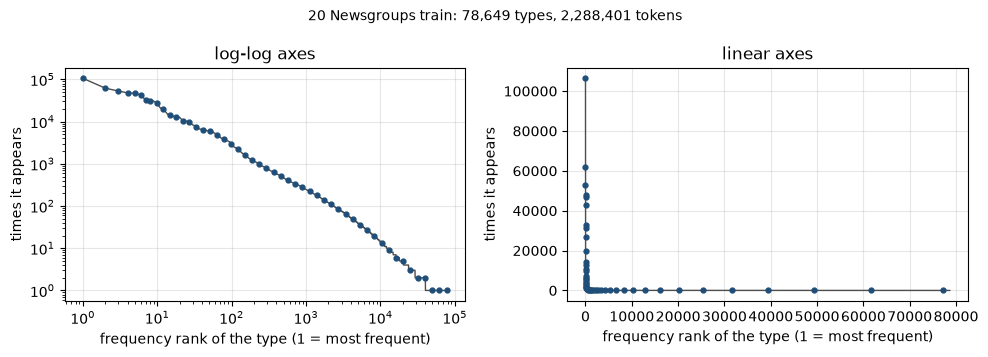

In [28]:
print("top 10:", counts.most_common(10), "\n")
vs_book("count of the tenth-ranked word", int(freqs[9]), 26_985)
vs_book("alpha=1 prediction, nearest 100", round(freqs[0] / 10, -2), 10_600, "{:,.0f}")

# the 50 (rank, count) pairs the chapter's Zipf widget plots
widget = [[1,106425],[2,62043],[3,53106],[4,47904],[5,46982],[6,42709],
  [7,32582],[8,31122],[10,26985],[12,19968],[15,14465],[18,12849],[22,10623],
  [27,9594],[33,7386],[41,6359],[51,5877],[63,4832],[78,3949],[97,3027],
  [121,2227],[151,1611],[188,1238],[235,972],[293,779],[366,625],[457,511],
  [571,405],[713,337],[891,276],[1113,221],[1391,178],[1738,139],[2172,109],
  [2715,84],[3393,65],[4241,49],[5301,36],[6626,27],[8282,19],[10352,13],
  [12940,9],[16175,6],[20218,5],[25272,3],[31590,2],[39487,2],[49358,1],
  [61697,1],[77121,1]]
same = sum(int(freqs[r - 1]) == f for r, f in widget)
print(f"\nwidget sample points reproduced: {same} of {len(widget)}")

ranks = np.arange(1, len(freqs) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, scale in zip(axes, ["log", "linear"]):
    ax.plot(ranks, freqs, lw=1, color="0.3")
    ax.plot([r for r, _ in widget], [f for _, f in widget], "o", ms=3.5, color="#1F4E79")
    ax.set_xscale(scale)
    ax.set_yscale(scale)
    ax.set_xlabel("frequency rank of the type (1 = most frequent)")
    ax.set_ylabel("times it appears")
    ax.set_title("log-log axes" if scale == "log" else "linear axes")
    ax.grid(alpha=0.3)
fig.suptitle(f"20 Newsgroups train: {len(counts):,} types, {len(tokens):,} tokens", fontsize=10)
fig.tight_layout()
plt.show()

**Nasıl okunur.** Log-log eksende eğri bir doğruya yakın; baş kısmı ise $1/r$ referansını
izlemiyor. Doğrusal eksende seyrek türler arasındaki farklar grafiğin alt bölümünde
sıkışıyor. İki panelde dağılım aynı; değişen yalnızca görünümü. Noktalar etkileşimli
grafiğin 50 örnek sırası; bütün sıralardan geçen çizgi ise verinin kendisi, uydurulmuş bir
model değil.

### Stop word kutusuna dönüş

Bölümün normalleştirme kısmındaki uyarı: bu derlemde `scikit-learn`'ün İngilizce stop word
listesi 318 maddeden oluşuyor; bunların 311'i bu tokenleştirmeyle derlemde geçiyor ve
sözlüğün yaklaşık %0,4'ünü, bütün token'ların %43,9'unu oluşturuyor. Hücre
"sözlük" ve "token" kelimelerini yukarıdaki 78.649 tür ve 2.288.401 token olarak okuyor.

In [29]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_tokens = sum(counts[w] for w in ENGLISH_STOP_WORDS)
vs_book("entries in the English stop word list", len(ENGLISH_STOP_WORDS), 318)
vs_book("share of the vocabulary, %", 100 * len(ENGLISH_STOP_WORDS) / len(counts), 0.4, "{:.1f}")
vs_book("share of all tokens, %", 100 * stop_tokens / len(tokens), 43.9, "{:.1f}")
present = sum(w in counts for w in ENGLISH_STOP_WORDS)
vs_book("entries that occur in this corpus", present, 311)

entries in the English stop word list  this run       318   book       318   same as the book
share of the vocabulary, %             this run       0.4   book       0.4   same as the book
share of all tokens, %                 this run      43.9   book      43.9   same as the book
entries that occur in this corpus      this run       311   book       311   same as the book


### `min_df` ve stop word listesi neleri siler

Bölümün üç pratik noktasından ikincisi iki filtreyi sayıya döküyor: eğitim bölümünün
tamamında, `CountVectorizer` nesnesinin varsayılan ayarlarıyla. `min_df=2`, ikiden az
belgede geçen her terimi atar; stop word listesi ise sabit bir kelime kümesini. Bölüm kod
vermiyor. **Bizim okuyuşumuz:** tek bir varsayılan `CountVectorizer` eğitimi; belge
frekansları ve geçiş toplamları onun matrisinden okunuyor.

**Neye bakacaksınız:** her filtrenin sütunlardaki payı ile token geçişlerindeki payı.

In [30]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

cv_all = CountVectorizer()
X_all = cv_all.fit_transform(docs)
names_all = cv_all.get_feature_names_out()
occ_all = np.asarray(X_all.sum(axis=0)).ravel()            # her terimin geçiş sayısı
df_all = np.asarray((X_all > 0).sum(axis=0)).ravel()       # her terimi içeren belge sayısı

rare = df_all < 2
vs_book("columns, default CountVectorizer", len(names_all), 101_631)
vs_book("columns removed by min_df=2", int(rare.sum()), 62_208)
vs_book("  their share of the columns, %", 100 * rare.mean(), 61, "{:.0f}")
vs_book("  their share of token occurrences, %", 100 * occ_all[rare].sum() / occ_all.sum(), 3.4, "{:.1f}")

stop = np.array([w in ENGLISH_STOP_WORDS for w in names_all])
vs_book("columns removed by the stop word list", int(stop.sum()), 309)
vs_book("  their share of token occurrences, %", 100 * occ_all[stop].sum() / occ_all.sum(), 43, "{:.0f}")
print("\nstop words the default token pattern never produces:",
      sorted(w for w in ENGLISH_STOP_WORDS if w in counts and w not in cv_all.vocabulary_))

columns, default CountVectorizer       this run   101,631   book   101,631   same as the book
columns removed by min_df=2            this run    62,208   book    62,208   same as the book
  their share of the columns, %        this run        61   book        61   same as the book
  their share of token occurrences, %  this run       3.4   book       3.4   same as the book
columns removed by the stop word list  this run       309   book       309   same as the book
  their share of token occurrences, %  this run        43   book        43   same as the book

stop words the default token pattern never produces: ['a', 'i']


**Nasıl okunur.** `min_df=2` sütunların çoğunu, metnin ise çok azını siliyor; stop word
listesi çok az sütun, ama metnin neredeyse yarısını siliyor. Buradaki 309 ile yukarıdaki
311 arasındaki fark tokenizer'dan geliyor: varsayılan kalıp en az iki karakter istediği
için tek harfli `a` ve `i` hiç token olmuyor. Bu sayılar bu derleme ve bu eşiğe ait; doğruluk
hakkında henüz bir şey söylemiyorlar. 6. kısım aynı sayımı sınıflandırma derleminde
tekrarlıyor.

### Regresyon eğimi güvenilir bir Zipf üssü değildir

Bölümün derinleşme kutusu: log-log sıra–frekans grafiğine en küçük karelerle bir doğru
uydurmak dağılımın biçimini betimleyebilir; ama eğim tek başına ne güvenilir bir kuvvet
yasası kestirimidir ne de kuvvet yasasının uyduğunun kanıtı. Uyum için seçilen aralık ve
noktaların ağırlıklandırılması eğimi değiştirir; ağırlıksız bir uyuma çok sayıdaki seyrek
tür hâkim olur. Clauset, Shalizi ve Newman'ın yaklaşımı (2009; bölümün kaynakçasında)
ayrık veya sürekli bir kuvvet yasası modelini, veriden alınan bir alt kesim $x_{\min}$ ile
birlikte maksimum olabilirlikle kestirir ve uyumu, sentetik örneklemlerle karşılaştırılan
bir Kolmogorov–Smirnov uzaklığıyla değerlendirir.

**Bu hücre kitapta yok.** O argümanın iki parçalı küçük bir gösterimi:

1. **Gerçek veri, doğru cevap bilinmiyor.** Bu derlemde, farklı sıra aralıkları üzerinden
   uydurulan en küçük kareler üssü.
2. **Sentetik veri, cevap biliniyor.** Olasılıkları tam olarak $r^{-1}$ izleyen 2.000.000
   türlük bir sözlükten 2.288.401 token (bu derlemin boyutu) çekin; yani gerçek
   $\alpha$ değeri 1. Sonra iki yolla da uydurun. Maksimum olabilirlik kestirimi sayımların kendisi
   üzerinde çalışır: $\alpha$ sıra üssü, $P(f) \propto f^{-\gamma}$ biçiminde dağılan
   sayımlara karşılık gelir ve $\gamma = 1 + 1/\alpha$ olur. Kestirim $\gamma$ değerini
   $x_{\min}$ ve üstündeki sayımlar için bulur (ayrık normalleştirici için Hurwitz zeta
   fonksiyonuyla) ve KS uzaklığı en küçük olan $x_{\min}$ değerini seçer. Bölümün de
   söylediği gibi sayım dağılımının üssü ile sıra–frekans üssü aynı parametre değil; hücre
   ikisi arasında bu bağıntıyla geçiyor.

Bölüm böyle bir kestirim yapmıyor ve hiçbir sonucu üssün tam değerine bağlı değil.

In [31]:
from scipy.optimize import minimize_scalar
from scipy.special import zeta


def ols_exponent(freqs, lo=1, hi=None):
    """Minus the least-squares slope of log(count) on log(rank), over ranks lo..hi."""
    f = np.sort(freqs)[::-1]
    r = np.arange(1, len(f) + 1)
    keep = (r >= lo) & (r <= (hi or len(f)))
    return -np.polyfit(np.log(r[keep]), np.log(f[keep]), 1)[0]


def power_law_mle(x, candidates):
    """Discrete power-law fit P(x) ~ x^-gamma for x >= xmin; xmin chosen by the smallest KS distance."""
    best = None
    for xmin in candidates:
        tail = np.sort(x[x >= xmin])
        n, log_sum = len(tail), np.log(tail).sum()
        gamma = minimize_scalar(lambda g: g * log_sum + n * np.log(zeta(g, xmin)),
                                bounds=(1.01, 4), method="bounded").x
        values, first = np.unique(tail, return_index=True)
        ks = np.abs((1 - first / n) - zeta(gamma, values) / zeta(gamma, xmin)).max()
        if best is None or ks < best["KS"]:
            best = {"gamma": gamma, "xmin": int(xmin), "KS": ks, "n in tail": n}
    return best


print("1. 20 Newsgroups, least squares on log-log rank-frequency")
for label, lo, hi in [("ranks 1-10", 1, 10), ("ranks 1-1,000", 1, 1000),
                      ("ranks 1,000 and beyond", 1000, None), ("all ranks", 1, None)]:
    print(f"   {label:<24} alpha = {ols_exponent(freqs, lo, hi):.2f}")

rng = np.random.default_rng(42)
V = 2_000_000
p = 1.0 / np.arange(1, V + 1)
p /= p.sum()
sample_counts = np.bincount(rng.choice(V, size=len(tokens), p=p))
synthetic = sample_counts[sample_counts > 0]

print(f"\n2. synthetic corpus with true alpha = 1: {len(synthetic):,} types seen, "
      f"{int((synthetic == 1).sum()):,} of them once")
print(f"   least squares, all ranks        alpha = {ols_exponent(synthetic):.2f}")
print(f"   least squares, ranks 1-1,000    alpha = {ols_exponent(synthetic, 1, 1000):.2f}")
fit = power_law_mle(synthetic, range(1, 200))
print(f"   maximum likelihood              gamma = {fit['gamma']:.3f} -> alpha = 1/(gamma-1) = "
      f"{1 / (fit['gamma'] - 1):.2f}   (xmin = {fit['xmin']}, KS = {fit['KS']:.4f}, "
      f"{fit['n in tail']:,} types in the fitted tail)")

1. 20 Newsgroups, least squares on log-log rank-frequency
   ranks 1-10               alpha = 0.55
   ranks 1-1,000            alpha = 1.01
   ranks 1,000 and beyond   alpha = 1.42
   all ranks                alpha = 1.38

2. synthetic corpus with true alpha = 1: 460,751 types seen, 314,642 of them once
   least squares, all ranks        alpha = 0.74
   least squares, ranks 1-1,000    alpha = 1.00


   maximum likelihood              gamma = 2.026 -> alpha = 1/(gamma-1) = 0.98   (xmin = 9, KS = 0.0042, 18,853 types in the fitted tail)


**Nasıl okunur.** Gerçek derlemde en küçük kareler "üssü" hangi sıraları içeri
aldığınıza bağlı: en sık on kelime için 1'in epey altında, ilk bin için 1 civarında,
kuyruk için 1'in epey üstünde. Bunların hiçbiri *o* üs değil. Cevabın 1 olduğu bilinen
sentetik derlemde, bütün sıralar üzerinden en küçük kareler fena hâlde ıskalıyor; çünkü
çoğu 1 ya da 2 sayımlı yüz binlerce kuyruk noktası başa karşı oy üstünlüğü kuruyor. Alt
kesimi veriden seçilen maksimum olabilirlik kestirimi ise 1'e yakın düşüyor.

Yalnızca baş üzerinden en küçük kareler de sentetik veride yaklaşıyor, ama yalnızca cevabı
bildiğimiz ve hangi aralığı seçeceğimizi görebildiğimiz için. Gerçek veride bilmiyorsunuz.
Tam yordam uyumu değerlendirmek için parametreleri sentetik örneklemlerde yeniden kestirir
ve kuvvet yasasını alternatif dağılımlarla karşılaştırır; bu hücre ikisini de yapmıyor.

### Heaps yasası

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-heaps). İşlenen token sayısı arttıkça kaç farklı
türle karşılaştık? Hücre birikimli tür sayısını derlem boyunca ölçüyor ve ona log-log
uzayında bir doğru uyduruyor. Kod bölümün kodu. Uyum betimsel bir özet: noktalar tek bir
token dizisinin giderek uzayan başlangıç parçaları, bağımsız örneklemler değil; katsayılar
da bu belge sırasına ve bu aralığa ait.

In [32]:
record()
import numpy as np

seen, curve = set(), []
for i, tok in enumerate(tokens, 1):
    seen.add(tok)
    if i % 10_000 == 0:
        curve.append((i, len(seen)))

N, V = np.array(curve).T
# Mevcut birikimli eğri için log-log uzayında betimsel doğru uyumu.
beta, logK = np.polyfit(np.log(N), np.log(V), 1)
print(f"|V| ~ {np.exp(logK):.1f} * N^{beta:.3f}")
print("new types in the first 100,000 tokens:", V[9])
print(f"new types in tokens {N[-11] + 1:,}-{N[-1]:,}:", V[-1] - V[-11])
compare_with_book("""
|V| ~ 16.5 * N^0.580
new types in the first 100,000 tokens: 13497
new types in tokens 2,180,001-2,280,000: 1814
""")
print()
vs_book("K", float(np.exp(logK)), 16.5, "{:.1f}")
vs_book("beta", float(beta), 0.58, "{:.2f}")

|V| ~ 16.5 * N^0.580
new types in the first 100,000 tokens: 13497
new types in tokens 2,180,001-2,280,000: 1814



-> same as the book, line for line (3 lines)

K                                      this run      16.5   book      16.5   same as the book
beta                                   this run      0.58   book      0.58   same as the book


**Nasıl okunur.** $0 < \beta < 1$ olduğunda uydurulan eğri büyümeyi sürdürüyor, eğimi ise
küçülüyor. Son iki satır aynı şeyi ölçümde gösteriyor: ilk 100.000 token 13.497 tür
getiriyor, ölçülen son 100.000 token 1.814. Yeni türler gelmeye devam ediyor, ama giderek
daha seyrek. Modelin sınırsız büyümesi modelin bir özelliği; sonlu bir derlem, bir dilin
sonsuza kadar yeni tür üreteceğini kanıtlamaz. Karşılaştırma için bölüm Reuters-RCV1
derlemi için bildirilen $K \approx 44$ ve $\beta \approx 0{,}49$ değerlerini veriyor.

### Her zaman ilk 50 listenize bakın

Bölümün kutusu: bu sayımda en sık *ikinci* token `'ax` ve bu, doğal dilde kullanılan bir
kelime değil. Bölüm sayısını, geçtiği belge sayısını, bu belgelerin ne olduğunu ve en büyük
tek katkının büyüklüğünü veriyor. Konu satırları aynı gönderilerin başlıkları atılmamış
hâlinden geliyor. Son kontrol `scikit-learn`'ün varsayılan `token_pattern` ayarını
kullanıyor; bu ayarda aynı içerik `ax` token'ını veriyor.

In [33]:
per_doc = [Counter(re.findall(r"[a-z']+", d.lower()))["'ax"] for d in docs]
ax_docs = [c for c in per_doc if c > 0]

vs_book("second most frequent token", counts.most_common(2)[1][0], "'ax", "{}")
vs_book("its count", counts["'ax"], 62_043)
vs_book("documents containing it", len(ax_docs), 13)
vs_book("share of documents, %", 100 * len(ax_docs) / len(docs), 0.1, "{:.1f}")
vs_book("largest single-document count", max(ax_docs), 11_147)


# aynı gönderiler, başlıkları atılmadan: 13 belgenin ne olduğunu görmek için
raw = fetch_20newsgroups(subset="train", data_home=DATA_HOME)
subject = lambda i: re.search(r"^Subject: *(.*)$", raw.data[i], re.M).group(1).strip()
print()
for i in sorted((i for i, c in enumerate(per_doc) if c), key=lambda i: -per_doc[i]):
    is_reply = bool(re.search(r"^References:", raw.data[i].split("\n\n")[0], re.M))
    print(f"  {per_doc[i]:>6}  {subject(i)[:44]:<44}  {'reply' if is_reply else 'not a reply'}")
print()
roman = [i for i, c in enumerate(per_doc) if c and subject(i).startswith("roman")]
vs_book("of them, parts of the roman.bmp posting", len(roman), 12)
vs_book("occurrences in the thirteenth document", min(ax_docs), 1)

order = np.argsort(-occ_all, kind="stable")                 # yukarıdaki varsayılan CountVectorizer eğitimi
rank_ax = int(np.where(names_all[order] == "ax")[0][0]) + 1
vs_book("rank of ax, default token_pattern", rank_ax, 2)
vs_book("its count, default token_pattern", int(occ_all[cv_all.vocabulary_["ax"]]), 62_387)
print("an 'AX line from the largest document:", repr(next(l for l in docs[int(np.argmax(per_doc))].splitlines() if "'AX" in l)[:44]))

second most frequent token             this run       'ax   book       'ax   same as the book
its count                              this run    62,043   book    62,043   same as the book
documents containing it                this run        13   book        13   same as the book
share of documents, %                  this run       0.1   book       0.1   same as the book
largest single-document count          this run    11,147   book    11,147   same as the book

   11147  roman.bmp 12/14                               not a reply
    9632  roman.bmp 13/14                               not a reply
    9156  roman.bmp 11/14                               not a reply
    7638  roman.bmp 07/14                               not a reply
    5944  roman.bmp 08/14                               not a reply
    4893  roman.bmp 09/14------------ Part 9 of 14 ---  not a reply
    4304  roman.bmp 06/14                               not a reply
    3490  roman.bmp 14/14                            

**Nasıl okunur.** On üç belgenin on ikisi, `roman.bmp` adlı bir dosyayı on dört parça
hâlinde taşıyan tek bir gönderi dizisinin parçaları; on üçünden hiçbiri bir cevap değil.
Gövdelerinde dosyanın metne kodlanmış (uuencode) içeriği var; art arda gelen aynı baytlar
en son basılan satırdaki gibi satırlar üretiyor. Toplam geçiş sayısına göre `'ax` bu
işlenmiş derlemde ikinci sırada; belge frekansına göre ise belgelerin yaklaşık %0,1'inde.
Derlem toplamındaki sıklık ile belgeler arasındaki yaygınlık farklı şeyler.

Baştaki kesme işareti ham veride zaten var. Bizim düzenli ifademiz onu token'ın içine
alıyor, küçük harfe çevirme de `AX` parçasını `ax` yapıyor; varsayılan `token_pattern`
kesme işaretini dışarıda bırakıp `ax` veriyor ve o da bu ayarda ikinci sırada. İçerik
aynı; token'ın biçimi bir ön işleme kararı. Sonraki kısımdaki TF-IDF bu iki sayımı birlikte
kullanıyor, ama doğal dil dışındaki içeriği kendiliğinden tanımıyor: az belgede görülen
bir gürültü dizisi yüksek IDF alabilir.

## 3. Bir kelime nasıl vektöre dönüşür

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-vektorler). Dört kısa bakım kaydı, karakter dizilerinden
üzerinde uzaklık hesaplayabileceğiniz vektörlere kadar, her ara sayı gösterilerek.

### 1. adım: sözlük sadece bir dizindir

In [34]:
record()
corpus = [
    "the pump failed",           # d1
    "the pump was replaced",     # d2
    "the valve failed",          # d3
    "the seal leak was repaired", # d4
]

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X = cv.fit_transform(corpus)
print(cv.get_feature_names_out())
compare_with_book("""
['failed' 'leak' 'pump' 'repaired' 'replaced' 'seal' 'the' 'valve' 'was']
""")

['failed' 'leak' 'pump' 'repaired' 'replaced' 'seal' 'the' 'valve' 'was']



-> same as the book, line for line (1 lines)


### 2 ve 3. adımlar: one-hot vektörler ve bir belgenin onların toplamı olması

Bölüm bu çıktıları kod olmadan basıyor; hücreler bizim okuyuşumuz. **Neye bakacaksınız:**
iki farklı one-hot vektörün iç çarpımı her zaman sıfır, dolayısıyla bu kodlamada farklı
kelimelerin vektörleri birbirine dik. Bir vektör yalnızca kendisiyle eşleşiyor.

In [35]:
vocab = list(cv.get_feature_names_out())
one_hot = lambda word: (np.array(vocab) == word).astype(int)

record()
print(f"index of 'pump': {cv.vocabulary_['pump']}")
print(f"one-hot: {one_hot('pump')}")
compare_with_book("""
index of 'pump': 2
one-hot: [0 0 1 0 0 0 0 0 0]
""")

record()
print(f"pump  : {one_hot('pump')}")
print(f"valve : {one_hot('valve')}")
print("        ------------------- multiply position by position")
print(f"        {one_hot('pump') * one_hot('valve')}  -> sum = {one_hot('pump') @ one_hot('valve')}")
compare_with_book("""
pump  : [0 0 1 0 0 0 0 0 0]
valve : [0 0 0 0 0 0 0 1 0]
        ------------------- multiply position by position
        [0 0 0 0 0 0 0 0 0]  -> sum = 0
""")

index of 'pump': 2
one-hot: [0 0 1 0 0 0 0 0 0]



-> same as the book, line for line (2 lines)
pump  : [0 0 1 0 0 0 0 0 0]
valve : [0 0 0 0 0 0 0 1 0]
        ------------------- multiply position by position
        [0 0 0 0 0 0 0 0 0]  -> sum = 0



-> same as the book, line for line (4 lines)


In [36]:
analyzer = cv.build_analyzer()
d1_tokens = analyzer(corpus[0])

record()
print(f"d1 tokens: {d1_tokens}")
print(f"d1 vector: {sum(one_hot(t) for t in d1_tokens)}")
compare_with_book("""
d1 tokens: ['the', 'pump', 'failed']
d1 vector: [1 0 1 0 0 0 1 0 0]
""")
print(f"same as CountVectorizer's row for d1: {bool((X[0].toarray()[0] == sum(one_hot(t) for t in d1_tokens)).all())}\n")

record()
counts_matrix = X.toarray()
print(f"{'':<8}" + "".join(f"{d:>4}" for d in ["d1", "d2", "d3", "d4"]))
for j, term in enumerate(vocab):
    print(f"{term:<8}" + "".join(f"{v:>4}" for v in counts_matrix[:, j]))
compare_with_book("""
          d1  d2  d3  d4
failed     1   0   1   0
leak       0   0   0   1
pump       1   1   0   0
repaired   0   0   0   1
replaced   0   1   0   0
seal       0   0   0   1
the        1   1   1   1
valve      0   0   1   0
was        0   1   0   1
""")

d1 tokens: ['the', 'pump', 'failed']
d1 vector: [1 0 1 0 0 0 1 0 0]



-> same as the book, line for line (2 lines)
same as CountVectorizer's row for d1: True

          d1  d2  d3  d4
failed     1   0   1   0
leak       0   0   0   1
pump       1   1   0   0
repaired   0   0   0   1
replaced   0   1   0   0
seal       0   0   0   1
the        1   1   1   1
valve      0   0   1   0
was        0   1   0   1



-> same as the book, line for line (10 lines)


### 4. adım: her kelime aynı ağırlığı hak eder mi?

`scikit-learn`'ün düzleştirilmiş ters doküman frekansı:

$$\mathrm{idf}(t) = \ln\!\left(\frac{1 + n}{1 + \mathrm{df}(t)}\right) + 1$$

İlk üç kod satırı bölümün. Bölüm altındaki tabloyu basma kodu olmadan basıyor ve `T`'yi
üreten çağrıyı göstermeden `TfidfVectorizer` adını veriyor; ikisi de bizim okuyuşumuz. `T`
5 ve 6. adımlarda yeniden kullanılıyor.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

n = len(corpus)
df = (X.toarray() > 0).sum(axis=0)
idf_manual = np.log((1 + n) / (1 + df)) + 1

tfidf = TfidfVectorizer()
T = tfidf.fit_transform(corpus)

record()
print(f"{'':<8}{'df':>4}{'idf':>8}")
for term, d, w in zip(vocab, df, idf_manual):
    print(f"{term:<8}{d:>4}{w:>8.4f}")
print()
with np.printoptions(precision=4):
    print(f"sklearn idf_: {tfidf.idf_}")
print(f"max abs diff vs manual: {np.abs(tfidf.idf_ - idf_manual).max()}")
compare_with_book("""
          df     idf
failed     2  1.5108
leak       1  1.9163
pump       2  1.5108
repaired   1  1.9163
replaced   1  1.9163
seal       1  1.9163
the        4  1.0000
valve      1  1.9163
was        2  1.5108

sklearn idf_: [1.5108 1.9163 1.5108 1.9163 1.9163 1.9163 1. 1.9163 1.5108]
max abs diff vs manual: 0.0
""")

          df     idf
failed     2  1.5108
leak       1  1.9163
pump       2  1.5108
repaired   1  1.9163
replaced   1  1.9163
seal       1  1.9163
the        4  1.0000
valve      1  1.9163
was        2  1.5108

sklearn idf_: [1.5108 1.9163 1.5108 1.9163 1.9163 1.9163 1.     1.9163 1.5108]
max abs diff vs manual: 0.0



-> same values as the book (13 lines); only the spacing differs


**Gerçek derlemde yayılım çok daha büyük.** Bölüm 20 Newsgroups'tan beş kelime basıyor,
kodunu vermeden. **Bizim okuyuşumuz:** 2. kısımdaki aynı `[a-z']+` token'ları üzerinde
doküman frekansları ve $n$ = 11.314 ile düzleştirilmiş formül. Bu okuyuş her basamağı
yeniden üretiyor. Hücre sonra sayımı `scikit-learn`'ün varsayılan `token_pattern`'ıyla
tekrarlıyor; bir tokenizer tercihinin sayıları nasıl oynattığını göstermek için.

In [38]:
doc_freq = Counter()
for d in docs:
    doc_freq.update(set(re.findall(r"[a-z']+", d.lower())))
N_docs = len(docs)

record()
for w in ["the", "is", "car", "encryption", "gravitational"]:
    idf_w = np.log((1 + N_docs) / (1 + doc_freq[w])) + 1
    print(f"{w:<14} df={doc_freq[w]:>6}  df/N={doc_freq[w] / N_docs:6.3f}  idf={idf_w:5.2f}")
compare_with_book("""
the            df=  9477  df/N= 0.838  idf= 1.18
is             df=  7034  df/N= 0.622  idf= 1.48
car            df=   394  df/N= 0.035  idf= 4.35
encryption     df=   169  df/N= 0.015  idf= 5.20
gravitational  df=     8  df/N= 0.001  idf= 8.14
""")

print("\nwith the default token_pattern instead:",       # df_all: 2. kısımdaki varsayılan CountVectorizer eğitimi
      {w: int(df_all[cv_all.vocabulary_[w]]) for w in ["the", "is", "car", "encryption", "gravitational"]})

the            df=  9477  df/N= 0.838  idf= 1.18
is             df=  7034  df/N= 0.622  idf= 1.48
car            df=   394  df/N= 0.035  idf= 4.35
encryption     df=   169  df/N= 0.015  idf= 5.20
gravitational  df=     8  df/N= 0.001  idf= 8.14



-> same as the book, line for line (5 lines)

with the default token_pattern instead: {'the': 9475, 'is': 7028, 'car': 396, 'encryption': 169, 'gravitational': 8}


Bölümün etkileşimli IDF grafiği bir kelimenin belge payını sürükleyip ağırlığını izlemenizi
sağlıyor. Durağan sürümü: $n$ = 11.314 için aynı eğri, yukarıdaki beş kelime işaretlenmiş
hâlde.

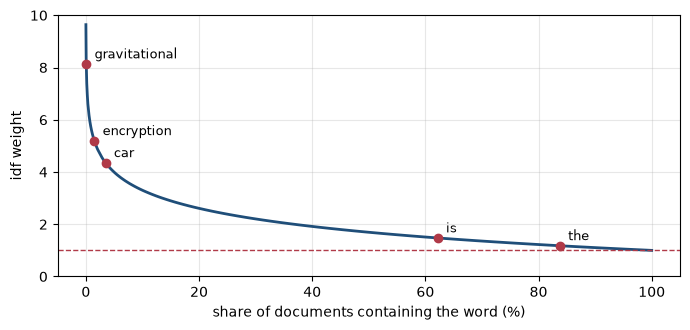

In [39]:
share_axis = np.linspace(1 / N_docs, 1, 2000)
idf_axis = np.log((1 + N_docs) / (1 + np.maximum(1, np.round(share_axis * N_docs)))) + 1

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(100 * share_axis, idf_axis, color="#1F4E79", lw=2)
ax.axhline(1, color="#B03A48", ls="--", lw=1)
for w in ["the", "is", "car", "encryption", "gravitational"]:
    s = doc_freq[w] / N_docs
    y = np.log((1 + N_docs) / (1 + doc_freq[w])) + 1
    ax.plot(100 * s, y, "o", color="#B03A48")
    ax.annotate(w, (100 * s, y), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("share of documents containing the word (%)")
ax.set_ylabel("idf weight")
ax.set_ylim(0, 10)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**Nasıl okunur.** Kesikli çizgi idf = 1 tabanını gösteriyor: bu formülde her belgede
geçen bir terimin IDF değeri 1. Belge oranındaki aynı büyüklükte artış, düşük oranlarda
ağırlığı daha çok değiştiriyor; daha yüksek oranlarda da IDF azalmayı sürdürüyor. Eğri,
terimin içerik kelimesi olup olmadığını değil, belgeler arasındaki yaygınlığını gösteriyor.

### 5. adım: çarp, sonra normalleştir

d1 (`the pump failed`) için: sayımları IDF ağırlıklarıyla çarpın, vektörün uzunluğuna
bölün ve `TfidfVectorizer`'ın satırıyla karşılaştırın. Basma kodu bizim okuyuşumuz. Son
satır bölümün şu notu: bu örnekte iki sonuç yuvarlama olmadan da uyuşuyor.

In [40]:
counts_d1 = X.toarray()[0]
weighted = counts_d1 * idf_manual
norm = np.linalg.norm(weighted)

record()
with np.printoptions(precision=4):
    print(f"counts        : {counts_d1}")
    print(f"times idf     : {weighted}")
    print(f"l2 norm       : {norm:.4f}")
    print(f"normalized    : {weighted / norm}")
    print(f"sklearn row d1: {T.toarray()[0]}")
compare_with_book("""
counts        : [1 0 1 0 0 0 1 0 0]
times idf     : [1.5108 0. 1.5108 0. 0. 0. 1. 0. 0.]
l2 norm       : 2.3591
normalized    : [0.6404 0. 0.6404 0. 0. 0. 0.4239 0. 0.]
sklearn row d1: [0.6404 0. 0.6404 0. 0. 0. 0.4239 0. 0.]
""")
print()
full = f"{norm:.12f}"
print(f"{'norm at full precision':<38} this run {full}   book 2.35906509...   "
      f"{'same as the book' if full.startswith('2.35906509') else 'DIFFERS from the book'}")
vs_book("max abs diff, hand vs TfidfVectorizer", np.abs(weighted / norm - T.toarray()[0]).max(), 0.0, "{:.1e}")

counts        : [1 0 1 0 0 0 1 0 0]
times idf     : [1.5108 0.     1.5108 0.     0.     0.     1.     0.     0.    ]
l2 norm       : 2.3591
normalized    : [0.6404 0.     0.6404 0.     0.     0.     0.4239 0.     0.    ]
sklearn row d1: [0.6404 0.     0.6404 0.     0.     0.     0.4239 0.     0.    ]



-> same values as the book (5 lines); only the spacing differs

norm at full precision                 this run 2.359065096782   book 2.35906509...   same as the book
max abs diff, hand vs TfidfVectorizer  this run   0.0e+00   book   0.0e+00   same as the book


Bölümün belge-terim matrisi bileşeni bütün TF-IDF matrisini üç ondalıkla basıyor. Bu
koşudan aynı matris:

In [41]:
widget_tfidf = np.array([
  [0.640,0.000,0.640,0.000,0.000,0.000,0.424,0.000,0.000],
  [0.000,0.000,0.497,0.000,0.631,0.000,0.329,0.000,0.497],
  [0.573,0.000,0.000,0.000,0.000,0.000,0.379,0.727,0.000],
  [0.000,0.507,0.000,0.507,0.000,0.507,0.264,0.000,0.400]])

print(f"{'':<4}" + "".join(f"{t:>9}" for t in vocab))
for name, row in zip(["d1", "d2", "d3", "d4"], T.toarray()):
    print(f"{name:<4}" + "".join(f"{v:>9.3f}" if v else f"{'.':>9}" for v in row))
matches = int((T.toarray().round(3) == widget_tfidf).sum())
print(f"\ncells equal to the widget's values at three decimals: {matches} of {widget_tfidf.size}")

       failed     leak     pump repaired replaced     seal      the    valve      was
d1      0.640        .    0.640        .        .        .    0.424        .        .
d2          .        .    0.497        .    0.631        .    0.329        .    0.497
d3      0.573        .        .        .        .        .    0.379    0.727        .
d4          .    0.507        .    0.507        .    0.507    0.264        .    0.400

cells equal to the widget's values at three decimals: 36 of 36


**Nasıl okunur.** Her satırda `the` sıfırdan farklı en küçük ağırlığı alıyor ve yalnızca
d3'te geçen `valve` matristeki en büyük hücre.

### 6. adım: belgeleri kosinüs benzerliği ile karşılaştırmak

Birim uzunluktaki vektörlerde kosinüs sadece iç çarpım ve yalnızca iki vektörün de sıfırdan
farklı olduğu konumlar katkı veriyor. Bölüm d1 ile d3'ü elle çalışıyor: iki canlı terim,
`failed` ve `the`.

In [42]:
Td = T.toarray()
j_failed, j_the = cv.vocabulary_["failed"], cv.vocabulary_["the"]
part_failed = Td[0, j_failed] * Td[2, j_failed]
part_the = Td[0, j_the] * Td[2, j_the]
cos13 = Td[0] @ Td[2]

print(f"cos(d1, d3) = {Td[0, j_failed]:.4f} x {Td[2, j_failed]:.4f} + {Td[0, j_the]:.4f} x {Td[2, j_the]:.4f}"
      f" = {part_failed:.4f} + {part_the:.4f} = {cos13:.3f}\n")
vs_book("d3's weight on failed", Td[2, j_failed], 0.5729, "{:.4f}")
vs_book("d3's weight on the", Td[2, j_the], 0.3792, "{:.4f}")
vs_book("failed's contribution", part_failed, 0.3669, "{:.4f}")
vs_book("the's contribution", part_the, 0.1607, "{:.4f}")
vs_book("cos(d1, d3)", cos13, 0.528, "{:.3f}")
vs_book("share supplied by failed, %", 100 * part_failed / cos13, 70, "{:.0f}")
vs_book("share supplied by the, %", 100 * part_the / cos13, 30, "{:.0f}")

cos(d1, d3) = 0.6404 x 0.5729 + 0.4239 x 0.3792 = 0.3669 + 0.1607 = 0.528

d3's weight on failed                  this run    0.5729   book    0.5729   same as the book
d3's weight on the                     this run    0.3792   book    0.3792   same as the book
failed's contribution                  this run    0.3669   book    0.3669   same as the book
the's contribution                     this run    0.1607   book    0.1607   same as the book
cos(d1, d3)                            this run     0.528   book     0.528   same as the book
share supplied by failed, %            this run        70   book        70   same as the book
share supplied by the, %               this run        30   book        30   same as the book


Bölümün bütün matris için verdiği kod tek satır, `cosine_similarity(T).round(3)`;
bastığı etiketli düzen ve ham sayım paneli bizim okuyuşumuz.

In [43]:
from sklearn.metrics.pairwise import cosine_similarity

S_tfidf = cosine_similarity(T).round(3)
S_counts = cosine_similarity(X).round(3)
names4 = ["d1", "d2", "d3", "d4"]


def show(S, label):
    print("  " + "".join(f"{d:>7}" for d in names4) + f"          <- {label}")
    for name, row in zip(names4, S):
        print(name + "".join(f"{v:7.3f}" for v in row))


record()
show(S_tfidf, "TF-IDF")
print()
show(S_counts, "raw counts")
compare_with_book("""
       d1     d2     d3     d4          <- TF-IDF
d1  1.000  0.458  0.528  0.112
d2  0.458  1.000  0.125  0.286
d3  0.528  0.125  1.000  0.100
d4  0.112  0.286  0.100  1.000

       d1     d2     d3     d4          <- raw counts
d1  1.000  0.577  0.667  0.258
d2  0.577  1.000  0.289  0.447
d3  0.667  0.289  1.000  0.258
d4  0.258  0.447  0.258  1.000
""")

print("\nhow much each pair drops, and what the two documents share")
sets = [set(analyzer(d)) for d in corpus]
for i in range(4):
    for j in range(i + 1, 4):
        shared = sorted(sets[i] & sets[j])
        print(f"  d{i + 1}-d{j + 1}  {S_counts[i, j]:.3f} -> {S_tfidf[i, j]:.3f}  "
              f"(drop {S_counts[i, j] - S_tfidf[i, j]:.3f})  shared: {shared}")

       d1     d2     d3     d4          <- TF-IDF
d1  1.000  0.458  0.528  0.112
d2  0.458  1.000  0.125  0.286
d3  0.528  0.125  1.000  0.100
d4  0.112  0.286  0.100  1.000

       d1     d2     d3     d4          <- raw counts
d1  1.000  0.577  0.667  0.258
d2  0.577  1.000  0.289  0.447
d3  0.667  0.289  1.000  0.258
d4  0.258  0.447  0.258  1.000



-> same as the book, line for line (11 lines)

how much each pair drops, and what the two documents share
  d1-d2  0.577 -> 0.458  (drop 0.119)  shared: ['pump', 'the']
  d1-d3  0.667 -> 0.528  (drop 0.139)  shared: ['failed', 'the']
  d1-d4  0.258 -> 0.112  (drop 0.146)  shared: ['the']
  d2-d3  0.289 -> 0.125  (drop 0.164)  shared: ['the']
  d2-d4  0.447 -> 0.286  (drop 0.161)  shared: ['the', 'was']
  d3-d4  0.258 -> 0.100  (drop 0.158)  shared: ['the']


**Nasıl okunur.** Farklı belgeler arasındaki bütün puanlar düşüyor; her belgenin kendisiyle
benzerliği 1 olarak kalıyor. En büyük dört düşüş, ortak zemini yalnızca `the` ya da
`the` ve `was` olan çiftler. İki kelime de `scikit-learn`'ün İngilizce stop word
listesinde. En küçük iki düşüş, bir içerik kelimesini — `pump` ya da `failed` — paylaşan
çiftler. Ve yalnızca `the`yi paylaşan d1 ile d4, 0,26'dan 0,11'e düşüyor. Kosinüs, iki
vektör arasındaki açının kosinüsüdür; anlamsal benzerliğin yüzdesi değil.

### Neden kosinüs, neden Öklid uzaklığı değil

Bölümün şekli iki kelime üzerinde üç belge kullanıyor: A = (2, 1); sayımları A'nın tam on
katı olan B = (20, 10); terim oranları farklı olan C = (1, 4). Hücre şekildeki ve altındaki sezgi
kontrolündeki her sayıyı yeniden hesaplıyor.

In [44]:
A, B, C = np.array([2.0, 1.0]), np.array([20.0, 10.0]), np.array([1.0, 4.0])
unit = lambda v: v / np.linalg.norm(v)
a, b, c = unit(A), unit(B), unit(C)
cos_ac = a @ c

vs_book("Euclidean ||A - C||", np.linalg.norm(A - C), 3.16, "{:.2f}")
vs_book("Euclidean ||A - B||", np.linalg.norm(A - B), 20.12, "{:.2f}")
ratio = np.linalg.norm(A - B) / np.linalg.norm(A - C)
print(f"{'times closer A is to C than to B':<38} this run {ratio:>9.2f}   book  'more than six'   {'consistent' if ratio > 6 else 'NOT consistent'}")
vs_book("angle between a and c, degrees", np.degrees(np.arccos(cos_ac)), 49.4, "{:.1f}")
vs_book("cos(a, c)", cos_ac, 0.651, "{:.3f}")
vs_book("||a - c||^2 = 2 - 2 cos", 2 - 2 * cos_ac, 0.698, "{:.3f}")
vs_book("||a - c||", np.sqrt(2 - 2 * cos_ac), 0.836, "{:.3f}")
print(f"\nafter normalization: a and b are the same point: {np.allclose(a, b)}; "
      f"||a - c|| measured directly = {np.linalg.norm(a - c):.3f}")
print(f"A's nearest neighbour  by raw Euclidean distance: {'C' if np.linalg.norm(A - C) < np.linalg.norm(A - B) else 'B'}"
      f"   by cosine: {'B' if a @ b > a @ c else 'C'}")

Euclidean ||A - C||                    this run      3.16   book      3.16   same as the book
Euclidean ||A - B||                    this run     20.12   book     20.12   same as the book
times closer A is to C than to B       this run      6.36   book  'more than six'   consistent
angle between a and c, degrees         this run      49.4   book      49.4   same as the book
cos(a, c)                              this run     0.651   book     0.651   same as the book
||a - c||^2 = 2 - 2 cos                this run     0.698   book     0.698   same as the book
||a - c||                              this run     0.836   book     0.836   same as the book

after normalization: a and b are the same point: True; ||a - c|| measured directly = 0.836
A's nearest neighbour  by raw Euclidean distance: C   by cosine: B


**$2 - 2\cos$ nereden geliyor.** Birim vektörler için
$\lVert a-b \rVert^2 = a \cdot a - 2\,a \cdot b + b \cdot b = 2 - 2\cos(a,b)$. Hücre
özdeşliği dört TF-IDF satırının bütün çiftlerinde kontrol ediyor, sonra bölümün çıkardığı
sonucu kontrol ediyor: vektörler sıfırdan farklıysa ve önceden normalleştirilmişse, Öklid
uzaklığıyla ve kosinüsle yapılan en yakın komşu araması aynı sıralı listeyi döndürüyor.
Sayısal eşiklerin ise iki ölçü arasında dönüştürülmesi gerekiyor.

In [45]:
sq_dist = ((Td[:, None, :] - Td[None, :, :]) ** 2).sum(axis=-1)
S = cosine_similarity(T)
print(f"max |squared distance - (2 - 2 cos)| over all 16 pairs: {np.abs(sq_dist - (2 - 2 * S)).max():.1e}")

same_rankings = all(
    list(np.argsort(sq_dist[i], kind="stable")) == list(np.argsort(-S[i], kind="stable"))
    for i in range(4))
print(f"every document's neighbours in the same order under both: {same_rankings}")

max |squared distance - (2 - 2 cos)| over all 16 pairs: 2.2e-16
every document's neighbours in the same order under both: True


## 4. Kelime torbasının yapamadıkları

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sec-metin-veri-sinirlar). Bölüm aşağıdaki iki cümleyi ve
çıktılarını basıyor; basma kodu bizim okuyuşumuz.

**Kelime sırasını temsil edemiyor.** Arızalanan ekipmanın zıt parçalarını adlandıran iki
rapor:

In [46]:
pair = ["the pump failed and the valve is fine",
        "the valve failed and the pump is fine"]

cv_pair = CountVectorizer()
P = cv_pair.fit_transform(pair).toarray()

record()
print(f"vocabulary: [{','.join(repr(t) for t in cv_pair.get_feature_names_out())}]")
print(f"row 1: {P[0]}")
print(f"row 2: {P[1]}")
print(f"vectors identical: {bool((P[0] == P[1]).all())}")
print(f"cosine similarity: {cosine_similarity(P)[0, 1].round(3)}")
compare_with_book("""
vocabulary: ['and','failed','fine','is','pump','the','valve']
row 1: [1 1 1 1 1 2 1]
row 2: [1 1 1 1 1 2 1]
vectors identical: True
cosine similarity: 1.0
""")

vocabulary: ['and','failed','fine','is','pump','the','valve']
row 1: [1 1 1 1 1 2 1]
row 2: [1 1 1 1 1 2 1]
vectors identical: True
cosine similarity: 1.0



-> same as the book, line for line (5 lines)


**n-gram'lar bir parçasını geri alıyor.** Tek kelimeler yerine komşu kelime çiftleri.
**Bizim okuyuşumuz:** yalnızca bigram (`ngram_range=(2, 2)`), yukarıdaki unigram hücresi
gibi ham sayımlarla. Aynı bigram'lar TF-IDF altında farklı bir kosinüs veriyor;
karşılaştırmanın altında basılıyor.

In [47]:
cv_bi = CountVectorizer(ngram_range=(2, 2))
P2 = cv_bi.fit_transform(pair)
bigrams = [repr(t) for t in cv_bi.get_feature_names_out()]

record()
print(f"bigram vocabulary: [{','.join(bigrams[:4])},")
print(f"{'':20}{','.join(bigrams[4:])}]")
print(f"cosine similarity: {cosine_similarity(P2)[0, 1]:.3f}")
print(f"vocabulary size: unigrams {len(cv_pair.vocabulary_)} -> bigrams {len(cv_bi.vocabulary_)}")
compare_with_book("""
bigram vocabulary: ['and the','failed and','is fine','pump failed',
                    'pump is','the pump','the valve','valve failed','valve is']
cosine similarity: 0.714
vocabulary size: unigrams 7 -> bigrams 9
""")
print(f"\nthe same bigrams under TF-IDF: cosine {cosine_similarity(TfidfVectorizer(ngram_range=(2, 2)).fit_transform(pair))[0, 1]:.3f}")

bigram vocabulary: ['and the','failed and','is fine','pump failed',
                    'pump is','the pump','the valve','valve failed','valve is']
cosine similarity: 0.714
vocabulary size: unigrams 7 -> bigrams 9



-> same as the book, line for line (4 lines)

the same bigrams under TF-IDF: cosine 0.559


**Olumsuzlamanın kapsamını temsil edemiyor.** Operasyonel anlamı zıt iki cümle. Son satır
bölümün uyarısını kontrol ediyor: içinde *no* geçen bir stop word listesiyle iki vektör
birebir aynı hâle geliyor (kosinüs 1).

In [48]:
neg = ["no leak was found", "a leak was found"]
cv_neg = CountVectorizer()
N_counts = cv_neg.fit_transform(neg)

record()
print(f'"{neg[0]}"  vs  "{neg[1]}"')
print('vocabulary (the default token_pattern drops the one-letter "a"):')
print(f"    {list(cv_neg.get_feature_names_out())}")
print(f"raw counts  ->  cosine {cosine_similarity(N_counts)[0, 1]:.3f}")
print(f"TF-IDF      ->  cosine {cosine_similarity(TfidfVectorizer().fit_transform(neg))[0, 1]:.3f}")
compare_with_book("""
"no leak was found"  vs  "a leak was found"
vocabulary (the default token_pattern drops the one-letter "a"):
    ['found', 'leak', 'no', 'was']
raw counts  ->  cosine 0.866
TF-IDF      ->  cosine 0.777
""")

cv_stop = CountVectorizer(stop_words="english")
N_stop = cv_stop.fit_transform(neg)
print(f"\nwith stop_words='english': vocabulary {list(cv_stop.get_feature_names_out())}, "
      f"cosine {cosine_similarity(N_stop)[0, 1]:.3f}  ('no' in the list: {'no' in ENGLISH_STOP_WORDS})")

"no leak was found"  vs  "a leak was found"
vocabulary (the default token_pattern drops the one-letter "a"):
    ['found', 'leak', 'no', 'was']
raw counts  ->  cosine 0.866
TF-IDF      ->  cosine 0.777



-> same as the book, line for line (5 lines)

with stop_words='english': vocabulary ['leak'], cosine 1.000  ('no' in the list: True)


## 5. Bütün bunların hâlâ bir önemi var mı?

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#bütün-bunların-hâlâ-bir-önemi-var-mı). Dört newsgroup, lojistik
regresyon, hiperparametre araması yok (`max_iter=2000` yakınsama için), metni özniteliğe
çevirmenin altı yolu. Kod bölümün
kodu, iki eklemeyle: önbellek için `data_home=DATA_HOME` ve her eğitilmiş hattı sonraki
hücreler için saklayan bir satır.

Bölümün durum notu bunun neden birebir yeniden üretildiğini açıklıyor: varsayılan `lbfgs`
çözücüsü hiç rastgelelik almıyor, dolayısıyla `random_state=0` burada fark etmiyor.

**Neye bakacaksınız:** altı doğruluk ve öznitelik sayısı. Veri, 2. kısımdaki aynı 20
Newsgroups arşivinden geliyor.

In [49]:
record()
start = time.perf_counter()
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

cats = ["sci.med", "sci.space", "rec.autos", "talk.politics.guns"]
drop = ("headers", "footers", "quotes")
train = fetch_20newsgroups(subset="train", categories=cats, remove=drop, data_home=DATA_HOME)
test = fetch_20newsgroups(subset="test", categories=cats, remove=drop, data_home=DATA_HOME)

setups = {
    "raw counts": CountVectorizer(),
    "counts + stop words": CountVectorizer(stop_words="english"),
    "tf-idf": TfidfVectorizer(),
    "tf-idf + stop words": TfidfVectorizer(stop_words="english"),
    "tf-idf + bigrams": TfidfVectorizer(ngram_range=(1, 2)),
    "tf-idf + sublinear tf": TfidfVectorizer(sublinear_tf=True),
}

models, accuracy = {}, {}   # (added) keep each fitted pipeline and its accuracy
for name, vec in setups.items():
    clf = make_pipeline(vec, LogisticRegression(max_iter=2000, random_state=0))
    clf.fit(train.data, train.target)
    acc = accuracy_score(test.target, clf.predict(test.data))
    models[name], accuracy[name] = clf, acc   # (added)
    print(f"{name:<24} accuracy {acc:.3f}   "
          f"features {len(clf[0].get_feature_names_out()):>7}")
compare_with_book("""
raw counts               accuracy 0.767   features   32318
counts + stop words      accuracy 0.795   features   32014
tf-idf                   accuracy 0.831   features   32318
tf-idf + stop words      accuracy 0.853   features   32014
tf-idf + bigrams         accuracy 0.819   features  249522
tf-idf + sublinear tf    accuracy 0.843   features   32318
""")
print(f"\n{len(train.data):,} training and {len(test.data):,} test documents; "
      f"all six fits took {time.perf_counter() - start:.1f} s")

raw counts               accuracy 0.767   features   32318


counts + stop words      accuracy 0.795   features   32014


tf-idf                   accuracy 0.831   features   32318


tf-idf + stop words      accuracy 0.853   features   32014


tf-idf + bigrams         accuracy 0.819   features  249522


tf-idf + sublinear tf    accuracy 0.843   features   32318



-> same as the book, line for line (6 lines)

2,327 training and 1,550 test documents; all six fits took 4.5 s


**Dört çıkarım ve çekince.** Bölüm bu altı satırdan dört çıkarım okuyor, sonra bunların
nokta kestirimleri olduğu konusunda uyarıyor. Belgeleri bağımsız sayan binom yaklaşımıyla,
1.550 test belgesinde 0,83 civarındaki tek bir doğruluğun %95 aralığı kabaca ±1,9 puan
($1{,}96\sqrt{p(1-p)/n}$); böyle iki doğruluk bağımsız olsaydı farklarının aralığı kabaca
±2,6 puan olurdu.

In [50]:
features = {name: len(m[0].get_feature_names_out()) for name, m in models.items()}
gap = lambda x, y: 100 * (accuracy[x] - accuracy[y])

vs_book("train documents", len(train.data), 2_327)
vs_book("test documents", len(test.data), 1_550)
vs_book("1. tf-idf over raw counts, points", gap("tf-idf", "raw counts"), 6.4, "{:.1f}")
vs_book("2. stop words on tf-idf, points", gap("tf-idf + stop words", "tf-idf"), 2.2, "{:+.1f}")
vs_book("3. bigram feature multiplier", features["tf-idf + bigrams"] / features["tf-idf"], 7.7, "{:.1f}")
vs_book("3. tf-idf minus bigrams, points", gap("tf-idf", "tf-idf + bigrams"), 1.2, "{:.1f}")
vs_book("4. sublinear tf minus tf-idf, points", gap("tf-idf + sublinear tf", "tf-idf"), 1.2, "{:.1f}")
half = 100 * 1.96 * math.sqrt(0.83 * 0.17 / len(test.data))
vs_book("95% half-width near 0.83, points", half, 1.9, "{:.1f}")
vs_book("half-width of a difference, points", half * math.sqrt(2), 2.6, "{:.1f}")

train documents                        this run     2,327   book     2,327   same as the book
test documents                         this run     1,550   book     1,550   same as the book
1. tf-idf over raw counts, points      this run       6.4   book       6.4   same as the book
2. stop words on tf-idf, points        this run      +2.2   book      +2.2   same as the book
3. bigram feature multiplier           this run       7.7   book       7.7   same as the book
3. tf-idf minus bigrams, points        this run       1.2   book       1.2   same as the book
4. sublinear tf minus tf-idf, points   this run       1.2   book       1.2   same as the book
95% half-width near 0.83, points       this run       1.9   book       1.9   same as the book
half-width of a difference, points     this run       2.6   book       2.6   same as the book


**Nasıl okunur.** Bu aralıklar belirsizliğin ölçeğini veriyor, ama bağımsız kestirimler
varsayıyor; altı model ise *aynı* test belgelerinde ölçülüyor. Bir farkın belirsizliği
eşleştirilmiş tahminlerden hesaplanmalı.

**Eşleştirilmiş test.** McNemar testi, bir modelin doğru, diğerinin yanlış sınıflandırdığı
belgelerin sayılarını karşılaştırır; ikisinin de doğru ya da ikisinin de yanlış bildiği
belgeler sonucu etkilemez. Bölümün ileri notu, çıkarımlarının dayandığı dört karşılaştırma
için bu sayıları ve kesin (binom) p-değerini veriyor. Kod vermiyor. **Bizim okuyuşumuz:**
iki uyumsuz sayım üzerinde `scipy.stats.binomtest`.

In [51]:
from scipy.stats import binomtest

right = {name: m.predict(test.data) == test.target for name, m in models.items()}
book_rows = {("tf-idf", "raw counts"): (119, 20, "2.4e-18"),
             ("tf-idf + stop words", "tf-idf"): (86, 52, "0.0048"),
             ("tf-idf + bigrams", "tf-idf"): (17, 35, "0.018"),
             ("tf-idf + sublinear tf", "tf-idf"): (29, 11, "0.0064")}
threshold = 0.05 / len(book_rows)                          # Bonferroni, dört karşılaştırma
for (a, b), (book_a, book_b, book_p) in book_rows.items():
    only_a, only_b = int((right[a] & ~right[b]).sum()), int((~right[a] & right[b]).sum())
    p = binomtest(only_a, only_a + only_b, 0.5).pvalue
    print(f"{a}  against  {b}")
    vs_book("  only the first correct", only_a, book_a)
    vs_book("  only the second correct", only_b, book_b)
    vs_book("  exact McNemar p", p, float(book_p), "{:.2g}")
    print(f"  below the corrected threshold {threshold}: {p < threshold}")

tf-idf  against  raw counts
  only the first correct               this run       119   book       119   same as the book
  only the second correct              this run        20   book        20   same as the book
  exact McNemar p                      this run   2.4e-18   book   2.4e-18   same as the book
  below the corrected threshold 0.0125: True
tf-idf + stop words  against  tf-idf
  only the first correct               this run        86   book        86   same as the book
  only the second correct              this run        52   book        52   same as the book
  exact McNemar p                      this run    0.0048   book    0.0048   same as the book
  below the corrected threshold 0.0125: True
tf-idf + bigrams  against  tf-idf
  only the first correct               this run        17   book        17   same as the book
  only the second correct              this run        35   book        35   same as the book
  exact McNemar p                      this run     0.018  

**Nasıl okunur.** Dört karşılaştırma olduğu için Bonferroni düzeltmesiyle eşik
0,05/4 = 0,0125. TF-IDF, stop word ve `sublinear_tf` farkları bu eşiğin altında kalıyor;
bigram farkı kalmıyor. Bu p-değerleri yalnızca test belgelerinin örneklenmesinden gelen
belirsizliği ölçüyor: tek bir eğitim–test bölmesi, tek bir eğitim koşusu, tek bir veri
kümesi. Bölümün genelleme konusundaki uyarısı da yerinde duruyor: Türkçe ürün yorumlarında
[4. bölüm](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/04-karsilastirma.html) dört çıkarımın ikisinde tersini ölçüyor; orada en büyük tek kazancı
bigram'lar veriyor ve düz sayma TF-IDF'i geçiyor.

### Model okunabilir

Bölüm her sınıfın ağırlıklarının işaret ettiği kelimeleri kodsuz basıyor. **Bizim
okuyuşumuz:** en iyi satırın, `tf-idf + stop words`, sınıf başına en yüksek ağırlıklı
terimleri. Bölüm `rec.autos` için sekiz, diğerleri için yedi kelime listeliyor; hücre de o
kadarını karşılaştırıyor. Karşılaştırmanın altında, stop word'ler hâlâ içerideyken düz
`tf-idf`ten aynı liste.

In [52]:
def top_terms(model, k=8):
    terms = model[0].get_feature_names_out()
    coef = model[1].coef_
    return {train.target_names[c]: list(terms[np.argsort(-coef[i], kind="stable")[:k]])
            for i, c in enumerate(model[1].classes_)}


book_lengths = {"rec.autos": 8, "sci.med": 7, "sci.space": 7, "talk.politics.guns": 7}
record()
for cat, words_ in top_terms(models["tf-idf + stop words"]).items():
    print(f"{cat:<20} {', '.join(words_[:book_lengths[cat]])}")
compare_with_book("""
rec.autos            car, cars, engine, ford, oil, dealer, drive, price
sci.med              msg, doctor, disease, medical, pain, patients, treatment
sci.space            space, nasa, orbit, moon, launch, earth, spacecraft
talk.politics.guns   gun, guns, weapons, fbi, law, government, firearms
""")

print("\nthe same question to plain tf-idf, stop words kept:")
for cat, words_ in top_terms(models["tf-idf"]).items():
    print(f"{cat:<20} {', '.join(words_)}")

rec.autos            car, cars, engine, ford, oil, dealer, drive, price
sci.med              msg, doctor, disease, medical, pain, patients, treatment
sci.space            space, nasa, orbit, moon, launch, earth, spacecraft
talk.politics.guns   gun, guns, weapons, fbi, law, government, firearms



-> same as the book, line for line (4 lines)

the same question to plain tf-idf, stop words kept:
rec.autos            car, cars, engine, ford, dealer, oil, my, drive
sci.med              msg, is, doctor, disease, of, medical, my, patients
sci.space            space, nasa, orbit, moon, launch, earth, spacecraft, shuttle
talk.politics.guns   gun, guns, weapons, fbi, law, government, fire, firearms


**Nasıl okunur.** Model kendi kanıtını kelimelerle adlandırıyor. Stop word'ler
tutulduğunda birkaç işlev kelimesi (`is`, `of`, `my`) de listelere giriyor.

### Hesaplama maliyeti de düşük

Bölüm TF-IDF eğitim matrisinin boyutunu kodsuz basıyor. **Bizim okuyuşumuz:** 2.327 eğitim
belgesi üzerinde varsayılan `TfidfVectorizer`; yoğun boyut hücre başına 8 bayt, seyrek
boyut CSR dizilerinin gerçekte tuttuğu şey (float64 değerler, int32 sütun indeksleri, int32
satır işaretçileri); megabayt $10^6$ bayt. Bu yalnızca matris: sözlük, IDF değerleri ve
model katsayıları buna ekleniyor. Süre için bölüm, altı yapılandırmanın her birinin
ölçümlerin yapıldığı dizüstü bilgisayarda 2 saniyenin altında bittiğini bildiriyor;
yukarıdaki deney hücresi bu koşunun toplam süresini basıyor.

In [53]:
M = TfidfVectorizer().fit_transform(train.data)
dense_mb = M.shape[0] * M.shape[1] * 8 / 1e6
sparse_mb = (M.data.nbytes + M.indices.nbytes + M.indptr.nbytes) / 1e6

record()
print(f"shape: {M.shape}")
print(f"stored non-zeros: {M.nnz}")
print(f"density: {100 * M.nnz / (M.shape[0] * M.shape[1]):.3f}%")
print(f"dense float64 would need : {dense_mb:8.1f} MB")
print(f"sparse csr actually needs: {sparse_mb:8.1f} MB")
print(f"ratio: {dense_mb / sparse_mb:.0f}x")
compare_with_book("""
shape: (2327, 32318)
stored non-zeros: 234281
density: 0.312%
dense float64 would need :    601.6 MB
sparse csr actually needs:      2.8 MB
ratio: 213x
""")
print(f"\ndtypes: values {M.data.dtype}, column indices {M.indices.dtype}, row pointers {M.indptr.dtype}")

shape: (2327, 32318)
stored non-zeros: 234281
density: 0.312%
dense float64 would need :    601.6 MB
sparse csr actually needs:      2.8 MB
ratio: 213x



-> same as the book, line for line (6 lines)

dtypes: values float64, column indices int32, row pointers int32


### BM25, kodla

[Bölümdeki kısım](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#bunlar-gerçekte-nerede-çalışıyor). Bölüm BM25'i kodsuz ve sayısız,
bir formül olarak veriyor:

$$\mathrm{BM25}(q, d) = \sum_{t \in q} \mathrm{idf}(t) \cdot
\frac{c(t,d)\,(k_1 + 1)}{c(t,d) + k_1\!\left(1 - b + b\,\frac{|d|}{\mathrm{avgdl}}\right)}$$

**Bu hücre o formülün doğrudan bir yazımı, bir yeniden üretim değil.** Toplam sorgudaki
farklı terimler üzerinden alınıyor; $c(t,d)$ terimin belgedeki sayımı, $|d|$ belgenin token
cinsinden uzunluğu. Hücre, bölümün adını verdiği Lucene `BM25Similarity` varsayılanlarını
kullanıyor: $k_1 = 1{,}2$ ve $b = 0{,}75$. Bölüm
BM25'in idf'i için yalnızca "olasılıksal bir varyant" diyor; hücre Lucene'in kullandığını
kullanıyor: $\ln\left(1 + \frac{n - \mathrm{df} + 0{,}5}{\mathrm{df} + 0{,}5}\right)$.

**Neye bakacaksınız:** ilk tablo bölümün anlattığı doygunluğu gösteriyor: belge uzunluğu
sabitken terim $k_1 + 1 = 2{,}2$ sınırına yaklaşıyor. `sublinear_tf` seçeneğinin
$1 + \ln c$ ağırlığı da yavaşlıyor, ama bir tavanı yok ve aynı fonksiyon değil.
İkincisi belge uzunluğundaki $b$ düğmesini gösteriyor. Son satırlar 3. kısımdaki dört bakım
kaydını `pump failed` sorgusu için puanlıyor.

In [54]:
def bm25_tf(c, doc_len, avgdl, k1=1.2, b=0.75):
    """BM25's saturating term-frequency factor."""
    return c * (k1 + 1) / (c + k1 * (1 - b + b * doc_len / avgdl))


print("term frequency factor for a document of average length")
print(f"{'count c':>8} {'raw c':>7} {'1 + ln c':>9} {'BM25':>7}")
for cnt in [1, 2, 3, 5, 10, 100]:
    print(f"{cnt:>8} {cnt:>7} {1 + math.log(cnt):>9.2f} {bm25_tf(cnt, 1, 1):>7.2f}")

print("\none occurrence, in documents of different lengths")
print(f"{'|d| / avgdl':>12} {'b = 0':>7} {'b = 0.75':>9} {'b = 1':>7}")
for rel in [0.5, 1, 2, 4]:
    print(f"{rel:>12} {bm25_tf(1, rel, 1, b=0):>7.2f} {bm25_tf(1, rel, 1):>9.2f} {bm25_tf(1, rel, 1, b=1):>7.2f}")

lengths = X.toarray().sum(axis=1)
avgdl = lengths.mean()
bm25_idf = np.log(1 + (n - df + 0.5) / (df + 0.5))
query = ["pump", "failed"]
print(f"\nquery {' '.join(query)!r} over the four maintenance logs (avgdl = {avgdl})")
for i, d in enumerate(corpus):
    score = sum(bm25_idf[cv.vocabulary_[t]] * bm25_tf(X[i, cv.vocabulary_[t]], lengths[i], avgdl) for t in query)
    print(f"  d{i + 1}  {d:<28} BM25 {score:.3f}")

term frequency factor for a document of average length
 count c   raw c  1 + ln c    BM25
       1       1      1.00    1.00
       2       2      1.69    1.38
       3       3      2.10    1.57
       5       5      2.61    1.77
      10      10      3.30    1.96
     100     100      5.61    2.17

one occurrence, in documents of different lengths
 |d| / avgdl   b = 0  b = 0.75   b = 1
         0.5    1.00      1.26    1.38
           1    1.00      1.00    1.00
           2    1.00      0.71    0.65
           4    1.00      0.45    0.38

query 'pump failed' over the four maintenance logs (avgdl = 3.75)
  d1  the pump failed              BM25 1.510
  d2  the pump was replaced        BM25 0.675
  d3  the valve failed             BM25 0.755
  d4  the seal leak was repaired   BM25 0.000


**Nasıl okunur.** Sayım sütunu tırmanmaya devam ediyor, `1 + ln c` daha yavaş tırmanıyor,
ama BM25 2,2'ye doğru düzleşiyor: onuncu geçiş neredeyse hiçbir şey eklemiyor. $b = 0$ iken
belge uzunluğu yok sayılıyor; $b = 1$ iken ortalamanın iki katı uzunluktaki bir belgedeki
bir geçiş kabaca üçte iki kadar değerli. Sorguda `pump` ve `failed` dört kaydın ikisinde
geçiyor, dolayısıyla aynı idf'i alıyorlar; d3 d2'yi yalnızca daha kısa olduğu için
geçiyor. d1 iki kelimeyi de içeriyor ve birinci; d4 hiçbirini içermiyor ve sıfır alıyor.

## 6. Sezgi kontrollerinden ve mülakat sorularından çıkan sayılar

[Sezgi kontrolleri](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#sezgi-kontrolleri) · [Mülakat soruları](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#mülakat-soruları)

**1. sezgi kontrolü: `min_df`.** Dört kategorili eğitim kümesinde `min_df=5` sözlüğü
32.318'den 6.281'e indiriyor ve silinen sütunlar hâlâ token geçişlerinin %11,6'sını
taşıyor. `min_df=5` yalnızca toplamda bir kez görülen terimleri değil, beşten az belgede
geçen her terimi atıyor. **Bizim okuyuşumuz:** 2.327 eğitim belgesi üzerinde varsayılan
`CountVectorizer`.
`min_df=5` modelinin doğruluğu 4. alıştırma, o yüzden burada basılmıyor.

In [55]:
cv_train = CountVectorizer().fit(train.data)
C_train = cv_train.transform(train.data)
doc_counts = np.asarray((C_train > 0).sum(axis=0)).ravel()
occurrences = np.asarray(C_train.sum(axis=0)).ravel()
kept = doc_counts >= 5

vs_book("columns before min_df", len(doc_counts), 32_318)
vs_book("columns with min_df=5", int(kept.sum()), 6_281)
vs_book("share of columns removed, %", 100 * (1 - kept.mean()), 81, "{:.0f}")
vs_book("occurrences in removed columns, %", 100 * occurrences[~kept].sum() / occurrences.sum(), 11.6, "{:.1f}")
vs_book("CountVectorizer(min_df=5) agrees", len(CountVectorizer(min_df=5).fit(train.data).vocabulary_), 6_281)

columns before min_df                  this run    32,318   book    32,318   same as the book
columns with min_df=5                  this run     6,281   book     6,281   same as the book
share of columns removed, %            this run        81   book        81   same as the book
occurrences in removed columns, %      this run      11.6   book      11.6   same as the book


CountVectorizer(min_df=5) agrees       this run     6,281   book     6,281   same as the book


**3. sezgi kontrolü: her belgede geçen bir kelime.** Varsayılan `smooth_idf=True` ile IDF
değeri $\ln\frac{1+n}{1+n} + 1 = 1$. Bölüm şunu da ekliyor: `smooth_idf=False` ders
kitabındaki $\log(n/\mathrm{df})$ formülünü *vermez* (o 0 olurdu); `scikit-learn`
dışarıdaki $+1$ terimini korur. Hücre iki ayarı da dört bakım kaydında kontrol ediyor;
orada `the` her belgede, `pump` ise dört belgenin ikisinde geçiyor.

In [56]:
for smooth in [True, False]:
    vec = TfidfVectorizer(smooth_idf=smooth).fit(corpus)
    idf_of = dict(zip(vec.get_feature_names_out(), vec.idf_))
    print(f"smooth_idf={smooth}")
    vs_book("  idf of `the`, in 4 of 4 documents", idf_of["the"], 1.0, "{:.4f}")
    by_hand = math.log((1 + 4) / (1 + 2)) + 1 if smooth else math.log(4 / 2) + 1
    print(f"  idf of `pump`, in 2 of 4 documents      this run {idf_of['pump']:.4f}   "
          f"formula with the outer +1: {by_hand:.4f}   textbook log(n/df): {math.log(4 / 2):.4f}")

smooth_idf=True
  idf of `the`, in 4 of 4 documents    this run    1.0000   book    1.0000   same as the book
  idf of `pump`, in 2 of 4 documents      this run 1.5108   formula with the outer +1: 1.5108   textbook log(n/df): 0.6931
smooth_idf=False
  idf of `the`, in 4 of 4 documents    this run    1.0000   book    1.0000   same as the book
  idf of `pump`, in 2 of 4 documents      this run 1.6931   formula with the outer +1: 1.6931   textbook log(n/df): 0.6931


**5. sezgi kontrolü: kaybolan parça numarası.** Varsayılan `token_pattern` en az iki kelime
karakteri ister ve tireyi aşmaz; bu yüzden `P-101` içindeki ön eki kaybettirir. Kod bölümün
kodu (İngilizce baskıdaki metinle).

In [57]:
record()
text = ["P-101 / P-102 pump tripped"]
for name, pattern in [("default", r"(?u)\b\w\w+\b"), ("custom", r"(?u)\b\w[\w-]*\w\b")]:
    cv = CountVectorizer(token_pattern=pattern).fit(text)
    print(f"{name:<10} : {list(cv.get_feature_names_out())}")
compare_with_book("""
default    : ['101', '102', 'pump', 'tripped']
custom     : ['p-101', 'p-102', 'pump', 'tripped']
""")

default    : ['101', '102', 'pump', 'tripped']
custom     : ['p-101', 'p-102', 'pump', 'tripped']



-> same as the book, line for line (2 lines)


**Nasıl okunur.** `P-101`, `101` oldu; yani bir sayfa numarasındaki ya da bir basınç
değerindeki 101 ile aynı token. Sorgu da aynı çözümleyiciden geçiyorsa `101` üzerinden
eşleşme yine mümkün; hiç sonuç gelmemesi sorgu ile dizin çözümleyicileri arasındaki bir
uyumsuzluktan da kaynaklanabilir.

**Bir mülakat cevabı: WordPiece ne zaman `[UNK]` der.** Bölüm, bir tokenizer'ın bilinmeyen
token üretip üretmeyeceğini yalnızca bayt düzeyinde bir alfabenin belirlemediğini not
ediyor: çok dilli BERT'in tokenizer'ında, gerçekleştirimin sınırından uzun bir kelime,
bütün karakterleri bilinse bile `[UNK]` oluyor. Bölüm kod vermiyor. **Bizim okuyuşumuz:**
1d kısmındaki `bert-base-multilingual-cased` tokenizer dosyası; 100 ve 101 tane `a`
harfinden oluşan birer kelime üzerinde.

In [58]:
from tokenizers import Tokenizer

mbert = Tokenizer.from_pretrained("bert-base-multilingual-cased")
for n, book_pieces, book_first in [(100, 50, "aa"), (101, 1, "[UNK]")]:
    pieces = mbert.encode("a" * n, add_special_tokens=False).tokens
    vs_book(f"pieces for a word of {n} letters", len(pieces), book_pieces)
    vs_book("  the first piece", pieces[0], book_first, "{}")

pieces for a word of 100 letters       this run        50   book        50   same as the book
  the first piece                      this run        aa   book        aa   same as the book
pieces for a word of 101 letters       this run         1   book         1   same as the book
  the first piece                      this run     [UNK]   book     [UNK]   same as the book


**Mülakat cevaplarındaki aritmetik.** Düz aritmetik, veri yok: `float64` değerler ve 32
bit sütun indeksleriyle saklanan $10^6 \times 10^5$ bir belge-terim matrisi, bütün çiftler
için bir benzerlik matrisi ve yakın kopya tespiti için çift sayısı. Baytlar GB başına
$10^9$ ile çevriliyor.

In [59]:
cells_ = 10**6 * 10**5
nnz = cells_ // 1000                      # 0.1% density
vs_book("dense 10^6 x 10^5 at 8 bytes, GB", cells_ * 8 / 1e9, 800, "{:,.0f}")
vs_book("CSR at 0.1%, 12 bytes per value, GB", nnz * 12 / 1e9, 1.2, "{:.1f}")
vs_book("saving, values and indices, nearest 10", round(cells_ * 8 / (nnz * 12), -1), 670, "{:,.0f}")
print(f"{'saving, with int32 row pointers too':<38} this run {cells_ * 8 / (nnz * 12 + (10**6 + 1) * 4):>9,.0f}")
vs_book("CSR at 1% density, GB", cells_ // 100 * 12 / 1e9, 12, "{:,.0f}")
vs_book("dense cosine matrix, n = 50,000, GB", 50_000**2 * 8 / 1e9, 20, "{:,.0f}")

pairs = math.comb(10**8, 2)
vs_book("pairs among 10^8 documents", pairs, 5e15, "{:.0e}")
vs_book("days at 10^9 comparisons per second", pairs / 1e9 / 86_400, 58, "{:.0f}")

dense 10^6 x 10^5 at 8 bytes, GB       this run       800   book       800   same as the book
CSR at 0.1%, 12 bytes per value, GB    this run       1.2   book       1.2   same as the book
saving, values and indices, nearest 10 this run       670   book       670   same as the book
saving, with int32 row pointers too    this run       664
CSR at 1% density, GB                  this run        12   book        12   same as the book
dense cosine matrix, n = 50,000, GB    this run        20   book        20   same as the book
pairs among 10^8 documents             this run     5e+15   book     5e+15   same as the book
days at 10^9 comparisons per second    this run        58   book        58   same as the book


**Nasıl okunur.** Bölüm kazancı "kabaca 670×" diye yuvarlıyor: yalnızca değerler ve sütun
indeksleri sayıldığında 800 GB bölü 1,2 GB, 667× ediyor. CSR biçiminin ayrıca sakladığı
satır işaretçisi dizisi ($10^6 + 1$ tane dört baytlık tam sayı) bunu 664× yapıyor; nesne ek
yükü de bunun üstüne geliyor. 64 bit indekslerle seyrek maliyet daha da yüksek.

## 7. Alıştırmalar

Bunlar [2. bölümün kendi alıştırmalarını](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/02-metin-veri.html#alıştırmalar) yukarıdaki hücrelerden
başlayarak sürdürüyor.

1. **Tokenizer ekonomisi.** 1d kısmındaki iki metni kendi yazdığınız teknik bir Türkçe
   paragrafla ve onun İngilizce çevirisiyle değiştirip `cl100k_base` ve `o200k_base`
   altında token sayın. Önce aynı içeriğin iki dildeki token sayısı oranını hesaplayın.
   Ardından seçtiğiniz bir modelin, tarihini belirttiğiniz birim fiyatlarıyla ayda 100.000
   istek için yıllık maliyeti kestirin; girdi ve çıktı token'larını ayrı bildirin ve tek
   paragrafın bütün istekleri temsil ettiği varsayımını yazın. Orana güvenmeden önce kendi
   kelimelerinizden birkaçını, `ev` hücresinin yaptığı gibi, önünde boşlukla ve boşluksuz
   sayın: boşluk cevabınızı değiştiriyor mu?

2. **`vectorizer`'ı kırın.** Kendi alanınızdan on belge üzerinde bir `CountVectorizer`
   eğitip `get_feature_names_out()` çıktısını basın. En az iki yanlış token bulun (bozulmuş
   bir tanımlayıcı, birleşmiş bir çift, kaybolmuş bir birim). Sorun token sınırlarından
   kaynaklanıyorsa 6. kısmın `P-101` için yaptığı gibi `token_pattern` ile düzeltin;
   gerekiyorsa küçük harf dönüşümünü ya da ön işlemeyi de düzenleyin. Her değişikliğin
   hangi örneği düzelttiğini ve hangi yeni hataları doğurabileceğini raporlayın.

3. **Elle türetin.** d3 (`the valve failed`) için TF-IDF vektörünü kâğıt kalemle hesaplayın,
   sonra 3. kısımdaki `T.toarray()[2]` ile kontrol edin. Uyuşmazlık varsa önce TF tanımını,
   IDF formülünü, L2 normalleştirmesini ve token'ları, sonra sütun sırasını ve yuvarlamayı
   karşılaştırın; farkın nereden geldiğini belirtin.

4. **Tekrarlayın ve genişletin.** 5. kısımdaki `setups` sözlüğüne
   `"tf-idf + min_df=5": TfidfVectorizer(min_df=5)` ekleyip yeniden koşturun. Öznitelik
   sayısı ne kadar düştü? Sonra iki yapılandırmayı düzgün karşılaştırın: eğitim verisinden
   ayırdığınız bir doğrulama bölümünde doğruluk, öznitelik sayısı, bellek ve işlem süresiyle;
   test kümesini yalnızca seçimi tamamladıktan sonra kullanın. Yeni satırınızı 5. kısımdaki
   eşleştirilmiş teste ekleyin: düz `tf-idf` ile farkı düzeltilmiş eşiği aşıyor mu?

5. **Olumsuzlama hatasını bulun.** 4. kısımdaki olumsuzlama hücresini kullanarak kendi
   alanınızdan, operasyonel anlamı zıt ve TF-IDF altında kosinüs benzerliği 0,9'un üstünde
   iki belge kurgulayın. Sonra, yalnızca yüksek TF-IDF kosinüsüne bakarak iki belgenin aynı
   operasyonel kararı ifade ettiğine hükmetmenin neden uygun olmadığını açıklayan bir
   tasarım incelemesi cümlesi yazın; *not* gibi ayırt edici terimler korunuyorsa bir
   sınıflandırıcının bunları kullanabileceğini de ekleyin.

6. **Kendi verinizde Zipf.** 2. kısımdaki `docs` yerine kendi derleminizi koyup grafiği
   yeniden çizin. Çizgi log-log eksende düz görünüyor mu? İlk beş token ne ve içlerinde
   `'ax` gibi bir artefakt var mı?

7. **Mülakat alıştırması.**
   [Chip Huyen'in kitabının §8.2.1 bölümündeki](https://huyenchip.com/ml-interviews-book/contents/8.2.1-natural-language-processing.html)
   beş belgelik TF-IDF sıralama problemini, sorgu terimini üç kez geçiren belgeye dair devam
   sorusuyla birlikte kâğıt kalemle çözün. `TfidfVectorizer` ile kontrol etmeden önce terim
   kümesini, kelime biçimleri arasındaki eşlemeleri (`birds → bird`, `gets → get`,
   `loves → love`) ve TF-IDF varyantını sabitleyin. Sonra 5. kısımdaki BM25 hücresini
   deneyin: diğer değişkenler sabitken BM25 sonlu bir sınıra yaklaşır, `sublinear_tf` ise
   büyümeyi yalnızca yavaşlatır.

8. **Türkçe token maliyetini çok sayıda örnekte ölçün.** 1d kısmındaki ölçüm tek bir kısa
   metin çifti üzerindeydi. Elinizdeki paralel bir metinden 50 ile 100 arası cümle çifti
   toplayın ve her tokenizer için iki ayrı ölçüm yapın: her çiftte Türkçe/İngilizce token
   sayısı oranı ve her dilde 1.000 Unicode kod noktası başına token sayısı. Medyanı ve
   çeyrekler arası aralığı bildirin; tek metin çiftindeki ölçümün bu dağılımın neresine
   düştüğünü söyleyin.

Sırada ne var: [3. bölüm](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/03-gommeler.html) 2. adımın gösterdiği şeyi —
one-hot kodlamada farklı kelimeler arasında benzerlik bulunmaması — yoğun embedding'lerle düzeltiyor;
[4. bölüm](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/tr/chapters/04-karsilastirma.html) aynı türden bir karşılaştırmayı Türkçe
yorumlar üzerinde koşturuyor ve farklı kazananlar buluyor.

---

*Bu notebook'taki kod MIT lisanslı; anlatım CC BY 4.0. 20 Newsgroups verisi `scikit-learn`
tarafından Jason Rennie'nin hazırladığı "bydate" dağıtımından indiriliyor; o sayfa bir
lisans belirtmiyor, UCI Machine Learning Repository ise Twenty Newsgroups koleksiyonunu
CC BY 4.0 altında listeliyor. İki 1. madde metni, İnsan Hakları Evrensel Bildirgesi'nin
Birleşmiş Milletler tarafından yayımlanan resmî İngilizce ve Türkçe sürümleri. Tokenizer
sözlükleri `tiktoken` tarafından OpenAI'dan indiriliyor.*